<a href="https://colab.research.google.com/github/agustinivandinocco-python/pythonpracticateoria/blob/main/clase_05y06_2025_teoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formas de traer data a python

Hay muchas formas de obtener la materia prima de los datos para trabajar

  1. Leer un File en linea o local

      * 1.A- Leer un EXCEL asi como viene
      * 1.B- Leer un .csv o .txt y parsearlo
      * 1.C- Leer un ZIP (descomprimirlo ➜ parsear)
  
  2. Leer una tabla de datos en linea
  
  3. Usar un dataset
  
    * Estático de un paquete de python
  
    * De un repo específco de datos (Kaggle, HuggingFace, Github)

  5. Hacer webScraping

  6. Consumir un API

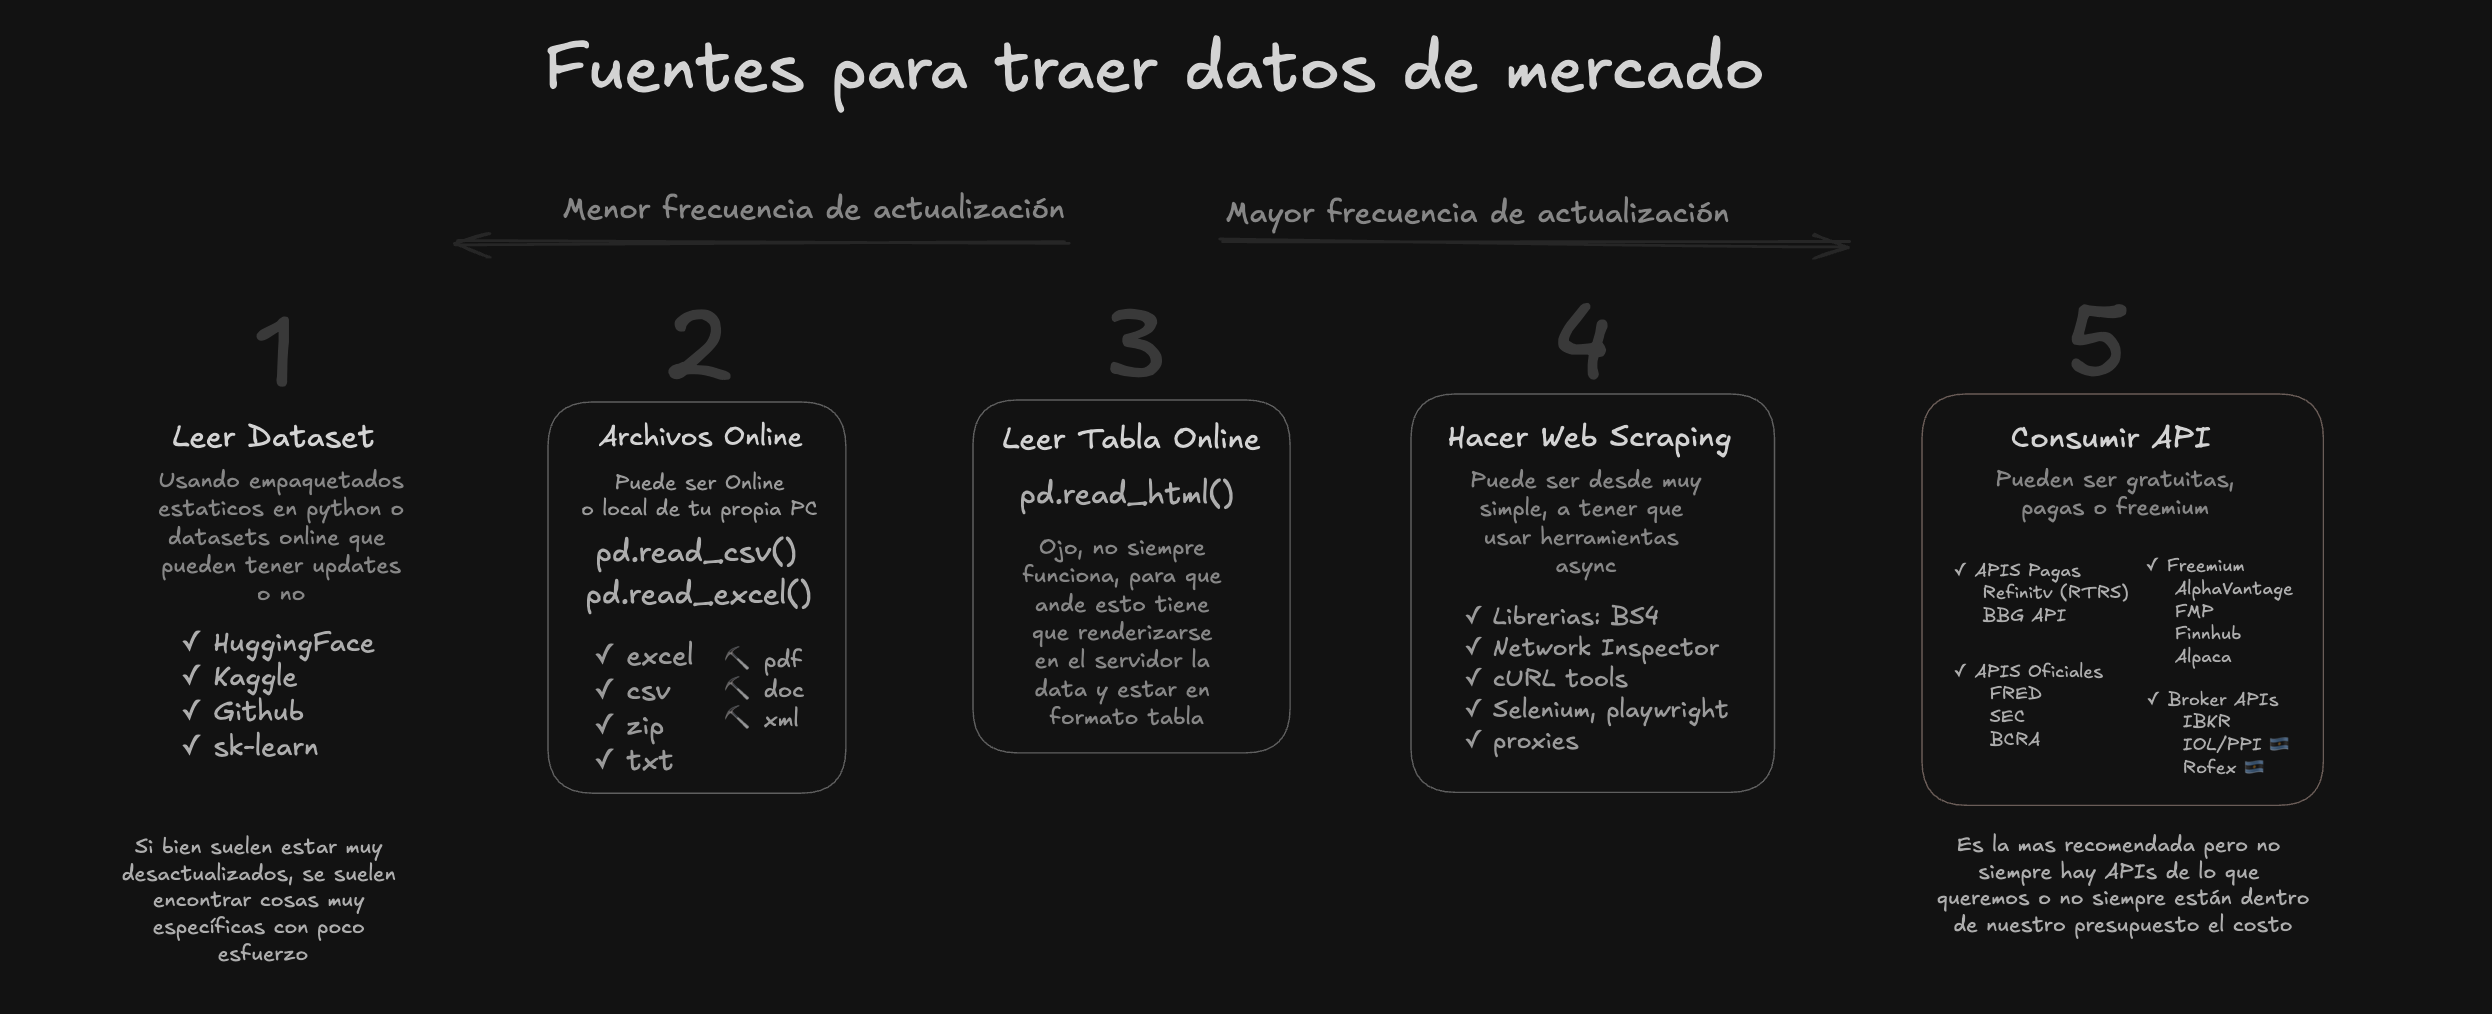

# 1 - Lectura de Datasets

## Ejemplo con dataset de seaborn, Dow Jones 1914-1968

In [ ]:
import seaborn as sns

df = sns.load_dataset("dowjones")
df

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45
...,...,...
644,1968-08-01,883.72
645,1968-09-01,922.80
646,1968-10-01,955.47
647,1968-11-01,964.12


In [ ]:
#sns.get_dataset_names()

## Interactividad de dataframes

In [ ]:
from google.colab import sheets

sh = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1BQN62NipnGbQjMas4u09_fFouK5w41tBRBMh-qpLXnI/edit#gid=0


## Ejemplo HuggingFace

https://huggingface.co/datasets?sort=trending&search=sp500

In [ ]:
# Debe instalarse datasets y reiniciar session

In [ ]:
!pip install datasets -q

In [ ]:
from datasets import load_dataset
import pandas as pd

id = "gauss314/options-IV-SP500"
data_iv = load_dataset(id)
df_iv = pd.DataFrame(data_iv['train'][:])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data_IV_USA.csv:   0%|          | 0.00/523M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3161661 [00:00<?, ? examples/s]

In [ ]:
df_iv.to_csv("opciones_usa.csv")

KeyboardInterrupt: 

In [ ]:
df_iv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3161661 entries, 0 to 3161660
Data columns (total 26 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Unnamed: 0              int64  
 1   symbol                  object 
 2   date                    object 
 3   strikes_spread          float64
 4   calls_contracts_traded  int64  
 5   puts_contracts_traded   int64  
 6   calls_open_interest     int64  
 7   puts_open_interest      int64  
 8   expirations_number      int64  
 9   DITM_IV                 float64
 10  ITM_IV                  float64
 11  sITM_IV                 float64
 12  ATM_IV                  float64
 13  sOTM_IV                 float64
 14  OTM_IV                  float64
 15  DOTM_IV                 float64
 16  contracts_number        int64  
 17  hv_20                   float64
 18  hv_40                   float64
 19  hv_60                   float64
 20  hv_75                   float64
 21  hv_90                   float64

In [ ]:
df_iv.groupby("symbol").size()

,0
symbol,
A,935
AA,928
AABA,29
AAC,109
AAL,935
...,...
ZTO,937
ZTS,937
ZUMZ,937


In [ ]:
df_iv.groupby("symbol").ATM_IV.mean().to_excel("IV_ATM.xlsx")

# 2 - Lectura Bajando un file (CSV/EXCEL)

## SP500 retornos reales, Dividendos, CPI, PE, desde 1871 a 2018

In [ ]:
import pandas as pd

In [ ]:
sp500_monthly = pd.read_csv('https://r2.datahub.io/clv1551hg0004mj09hjz069e9/main/raw/data/data.csv')
sp500_monthly

,Date,SP500,Dividend,Earnings,...,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.440000,0.26,0.40,...,109.05,6.39,9.82,0.00
1,1871-02-01,4.500000,0.26,0.40,...,107.25,6.20,9.53,0.00
2,1871-03-01,4.610000,0.26,0.40,...,108.27,6.11,9.39,0.00
3,1871-04-01,4.740000,0.26,0.40,...,115.54,6.34,9.75,0.00
4,1871-05-01,4.860000,0.26,0.40,...,121.22,6.48,9.98,0.00
...,...,...,...,...,...,...,...,...,...
1828,2023-05-01,4146.173182,68.54,179.17,...,4173.45,68.99,180.35,31.14
1829,2023-06-01,4345.372857,68.71,181.17,...,4359.88,68.94,181.77,32.41
1830,2023-07-01,4508.075500,0.00,0.00,...,4514.51,0.00,0.00,33.38
1831,2023-08-01,4457.358696,0.00,0.00,...,4459.48,0.00,0.00,32.91


In [ ]:
sp500_monthly.columns

Index(['Date', 'SP500', 'Dividend', 'Earnings', 'Consumer Price Index',
       'Long Interest Rate', 'Real Price', 'Real Dividend', 'Real Earnings',
       'PE10'],
      dtype='object')

In [ ]:
sp500_monthly.to_csv("sp500_monthly.csv")

In [ ]:
df_read = pd.read_csv('sp500_monthly.csv')
df_read

,Unnamed: 0,Date,SP500,Dividend,...,Real Price,Real Dividend,Real Earnings,PE10
0,0,1871-01-01,4.440000,0.26,...,109.05,6.39,9.82,0.00
1,1,1871-02-01,4.500000,0.26,...,107.25,6.20,9.53,0.00
2,2,1871-03-01,4.610000,0.26,...,108.27,6.11,9.39,0.00
3,3,1871-04-01,4.740000,0.26,...,115.54,6.34,9.75,0.00
4,4,1871-05-01,4.860000,0.26,...,121.22,6.48,9.98,0.00
...,...,...,...,...,...,...,...,...,...
1828,1828,2023-05-01,4146.173182,68.54,...,4173.45,68.99,180.35,31.14
1829,1829,2023-06-01,4345.372857,68.71,...,4359.88,68.94,181.77,32.41
1830,1830,2023-07-01,4508.075500,0.00,...,4514.51,0.00,0.00,33.38
1831,1831,2023-08-01,4457.358696,0.00,...,4459.48,0.00,0.00,32.91


In [ ]:
sp500_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1833 entries, 0 to 1832
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  1833 non-null   object 
 1   SP500                 1833 non-null   float64
 2   Dividend              1833 non-null   float64
 3   Earnings              1833 non-null   float64
 4   Consumer Price Index  1833 non-null   float64
 5   Long Interest Rate    1833 non-null   float64
 6   Real Price            1833 non-null   float64
 7   Real Dividend         1833 non-null   float64
 8   Real Earnings         1833 non-null   float64
 9   PE10                  1833 non-null   float64
dtypes: float64(9), object(1)
memory usage: 143.3+ KB


El PE10, o CAPE (Cyclically Adjusted Price-to-Earnings Ratio), fue idea de Robert J. Shiller

Es una versión ajustada del ratio Precio-Ganancias (P/E ratio), que mete un suavizado de 10 años ajustando por inflacion tanto el precio como las ganancias

## Shiller data (Update actualizado)

En 2013 se otorga el nobel de economia a 3 sujetos con ideas opuestas y complementarias para el abordaje de los sistemas financieros

  * Robert Shiller. (Conductualismo)
  * Eugene Fama.  (Mercados eficientes)
  * Lars Hansen. (Estadistica y proyeccion)

https://shillerdata.com/

In [ ]:
# url = "https://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/ie_data.xls?ver=1721057088918"
url = "https://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/4a0629e8-3f7f-4884-817b-81cf106d8f88/ie_data.xls?ver=1759496035247"

col_names = [
    "Date",
    "IndexPrice",
    "Dividend",
    "Earnings",
    "CPI",
    "DateFraction",
    "InterestRate",
    "RealPrice",
    "RealDividend",
    "RealReturnsPrice",
    "RealEarnings",
    "RealReturnsPriceScaledEarnings",
    "Adj_PE10_CAPE",
    "drop_col_1",
    "RealReturnsPriceScaledEarnings_CAPE",
    "drop_col_2",
    "Excess_CAPE_yield",
    "MonthlyRealTotalBonsReturn",
    "RealRealTotal_bonsReturn",
    "Annual_10yrStocksReturn",
    "Annual_10yrBondsReturn",
    "Total_10yrExcessReturns",
]
data = pd.read_excel(url, sheet_name="Data", skiprows=8, names=col_names, skipfooter=1)
data = data.drop(['drop_col_1','drop_col_2'],axis=1)
data.index = pd.to_datetime(data.Date.astype(str), format="%Y.%m")
data

,Date,IndexPrice,Dividend,Earnings,...,RealRealTotal_bonsReturn,Annual_10yrStocksReturn,Annual_10yrBondsReturn,Total_10yrExcessReturns
Date,,,,,,,,,
1871-02-01,1871.02,4.500000,0.260000,0.40,...,0.974424,0.130858,0.094635,0.036224
1871-03-01,1871.03,4.610000,0.260000,0.40,...,0.964209,0.130951,0.096186,0.034765
1871-04-01,1871.04,4.740000,0.260000,0.40,...,1.004919,0.122056,0.090972,0.031084
1871-05-01,1871.05,4.860000,0.260000,0.40,...,1.032591,0.122638,0.089488,0.033150
1871-06-01,1871.06,4.820000,0.260000,0.40,...,1.053249,0.123093,0.087725,0.035368
...,...,...,...,...,...,...,...,...,...
2025-06-01,2025.06,6029.951500,77.350000,222.53,...,39.394513,NaN,NaN,NaN
2025-07-01,2025.07,6296.498182,77.726667,NaN,...,39.447119,NaN,NaN,NaN
2025-08-01,2025.08,6408.949524,78.103333,NaN,...,39.891024,NaN,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1842 entries, 1871-02-01 to 2024-07-01
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Date                                     1842 non-null   float64
 1   Stock_returns                            1842 non-null   float64
 2   Dividend                                 1841 non-null   float64
 3   Earnings                                 1838 non-null   float64
 4   CPI                                      1842 non-null   float64
 5   Date_fraction                            1842 non-null   float64
 6   Long_interest_rate                       1842 non-null   float64
 7   Real_price                               1842 non-null   float64
 8   Real_dividend                            1841 non-null   float64
 9   Real_returns_price                       1842 non-null   float64
 10  Real_earnings                 

Para tener el dataset limpio solo los datos base para calcular ustedes y automaticamente actualizado con:

  - Valor indice (SP500 o equivalente acciones anteriores)
  - Dividendos nominales
  - Earnings de las empresas nominales
  - CPI para ajustar por inflacion
  - Tasa USA a 10 yr

https://colab.research.google.com/drive/1QWEFlWm9w10FCZUHNm5_CpDMqZMZ6Ht3?usp=sharing

## Lectura de data desde ZIP

https://github.com/gauss314/ucema

In [ ]:
import requests
import io
from zipfile import ZipFile

url = "https://github.com/gauss314/ucema/raw/main/opciones_hist_2020_Q1.zip"
r = requests.get(url)
zip_file = ZipFile(io.BytesIO(r.content))

# Esta linea es solo para extraer el nombre del archivo CSV dentro del ZIP
csv_file = zip_file.namelist()[0]

# Lee el archivo CSV con pandas
df = pd.read_csv(zip_file.open(csv_file))
df

,id,sigma10,sigma20,sigma40,sigma250,vi_ultima,vi_compra,vi_venta,strike,simbolo,...,subyacente,subyacente_precio,tipo,tiempo,ruedas_faltantes_opex,black_scholes,otm,valor_intrinseco,valor_extrinseco,fecha_negociado
0,273811,21,35,55,51,55.98,NaN,NaN,31.00,ALUC31.0FE,...,ALUA,32.4,Call,0.136986,36,4.343,-4,1.4,2.966,2019-12-27
1,273812,21,35,55,51,32.32,NaN,NaN,33.00,ALUC33.0AB,...,ALUA,32.4,Call,0.290411,76,5.385,2,NaN,4.000,2019-12-30
2,273813,21,35,55,51,46.22,NaN,NaN,33.00,ALUC33.0FE,...,ALUA,32.4,Call,0.136986,36,3.227,2,NaN,2.805,2019-12-30
3,273814,21,35,55,51,56.67,NaN,NaN,25.37,ALUV25.37F,...,ALUA,32.4,Put,0.136986,36,0.182,22,NaN,0.200,2019-12-30
4,273815,21,35,55,51,43.33,NaN,NaN,33.00,ALUV33.0FE,...,ALUA,32.4,Put,0.136986,36,2.054,-2,0.6,0.900,2019-12-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827628,1101439,236,198,143,74,97.25,NaN,NaN,960.00,YPFC960.JU,...,YPFD,345.5,Call,0.216438,57,12.090,178,NaN,1.553,2020-03-30
827629,1101440,236,198,143,74,129.13,NaN,NaN,300.00,YPFV300.AB,...,YPFD,345.5,Put,0.043836,12,18.334,13,NaN,15.167,2020-03-30
827630,1101441,236,198,143,74,132.78,NaN,NaN,400.00,YPFV400.AB,...,YPFD,345.5,Put,0.043836,12,72.811,-16,54.5,15.500,2020-03-30
827631,1101442,236,198,143,74,132.84,NaN,NaN,420.00,YPFV420.AB,...,YPFD,345.5,Put,0.043836,12,87.610,-22,74.5,10.500,2020-03-26


# 3 - Lectura de data desde tabla WEB

Este método sirve siempre y cuando:

  * La web se renderiza entera en el servidor (no se carga en forma asincrona)
  * Está la tabla como elemento <table> en el HTML

https://en.wikipedia.org/wiki/List_of_S%26P_500_companies

In [ ]:
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

html = requests.get(url, headers=headers).content
sp500_tickers = pd.read_html(html)[0]

In [ ]:
sp500_tickers

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [ ]:
# La dejo picando para scraping

# Se puede buscar todos los balances por CIK directo de edgar, en este caso ABBV
url = "https://www.sec.gov/edgar/browse/?CIK=1551152"

https://www.sec.gov/edgar/browse/?CIK=1551152

## Ejemplo de SDK Que hacen wrapers leyendo datos de la web

Es importante entender que hacen estos wrapers, basicamente webscraping, como el de yfinance (esto puede usar de fondo un API o no, ser mas rustico)

https://github.com/gauss314/secfi

In [ ]:
!pip install secfi -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.9/147.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.3/167.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.0/508.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.6/346.6 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.3/126.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 58.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is t

In [ ]:
import secfi
ciks = secfi.getCiks()
ciks

,cik_str,title,cik
ticker,,,
NVDA,1045810,NVIDIA CORP,0001045810
MSFT,789019,MICROSOFT CORP,0000789019
AAPL,320193,Apple Inc.,0000320193
GOOGL,1652044,Alphabet Inc.,0001652044
AMZN,1018724,AMAZON COM INC,0001018724
...,...,...,...
OSRHW,1840425,"OSR Holdings, Inc.",0001840425
MNSBP,1693577,"MainStreet Bancshares, Inc.",0001693577
MAYAR,2028355,Maywood Acquisition Corp.,0002028355


In [ ]:
filings = secfi.getFils("AAPL")
filings

,filingDate,reportDate,form,filmNumber,size,isXBRL,url,acceptanceDateTime
0,2025-10-31,2025-09-27,10-K,251437791,9392337,1,https://www.sec.gov/Archives/edgar/data/000032...,2025-10-31T10:01:26.000Z
1,2025-10-30,2025-10-30,8-K,251436166,453184,1,https://www.sec.gov/Archives/edgar/data/000032...,2025-10-30T20:30:35.000Z
2,2025-10-17,2025-10-15,4,,20911,0,https://www.sec.gov/Archives/edgar/data/000032...,2025-10-17T22:31:09.000Z
3,2025-10-17,2025-10-15,4,,15763,0,https://www.sec.gov/Archives/edgar/data/000032...,2025-10-17T22:30:16.000Z
4,2025-10-16,,144,251397914,4811,0,https://www.sec.gov/Archives/edgar/data/000032...,2025-10-16T20:23:19.000Z
...,...,...,...,...,...,...,...,...
996,2015-02-02,,SC 13G/A,15565636,13407,0,https://www.sec.gov/Archives/edgar/data/000032...,2015-02-02T17:12:47.000Z
997,2015-02-02,,424B2,15564954,412238,0,https://www.sec.gov/Archives/edgar/data/000032...,2015-02-02T13:46:07.000Z
998,2015-01-30,2015-01-26,3,,13347,0,https://www.sec.gov/Archives/edgar/data/000032...,2015-01-30T23:32:11.000Z
999,2015-01-28,2015-01-28,8-K,15555430,11968495,1,https://www.sec.gov/Archives/edgar/data/000032...,2015-01-28T21:48:46.000Z


In [ ]:
import secfi

last_nvda = secfi.scrapLatest("NVDA", "10-Q")

In [ ]:
last_nvda['text'][:20_000]

"STATESSECURITIES AND EXCHANGE COMMISSIONWashington, D.C.\xa020549FORM 10-Q ☒QUARTERLY REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934\nFor the quarterly period ended July\xa027, 2025OR☐TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934Commission File Number: 0-23985 NVIDIA CORPORATION(Exact name of registrant as specified in its charter) Delaware94-3177549(State or other jurisdiction of(I.R.S. Employerincorporation or organization)Identification No.)2788 San Tomas Expressway, Santa Clara, California95051(Address\xa0of principal executive offices)(Zip Code)(408) 486-2000 (Registrant's telephone number, including area code)N/A(Former name, former address and former fiscal year, if changed since last report)Securities registered pursuant to Section 12(b) of the Act:Title of each classTrading Symbol(s)Name of each exchange on which registeredCommon Stock, $0.001 par value per shareNVDAThe Nasdaq Global Select MarketIndica

In [ ]:
last_nvda.keys()

dict_keys(['filingDate', 'reportDate', 'form', 'filmNumber', 'size', 'isXBRL', 'url', 'acceptanceDateTime', 'text'])

# 5 - APIs

Este es un tema de la clase que viene, pero para tener para trabajar usaremos un wrapper del API gratuito de yahoo finance (que aun funciona) para traer datos de mercado actuales que como vemos trae los datos ya en un dataframe

In [ ]:
import yfinance as yf

In [ ]:
ggal = yf.download('AAPL', auto_adjust=True, start='2010-01-01')
ggal

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.424606,6.439316,6.375673,6.407194,493729600
2010-01-05,6.435712,6.472037,6.401789,6.442317,601904800
2010-01-06,6.333344,6.461230,6.326740,6.435713,552160000
2010-01-07,6.321634,6.364263,6.275704,6.356758,477131200
2010-01-08,6.363665,6.364266,6.276007,6.313231,447610800
...,...,...,...,...,...
2025-11-04,270.040009,271.489990,267.619995,268.329987,49274800
2025-11-05,270.140015,271.700012,266.929993,268.609985,43683100


In [ ]:
# Si no les anda yfinance, ejecuten una sola vez el codigo comentado de abajo, y listo, queda el notebook "habilitado" para usarlo todo lo que quieran

In [ ]:
# !pip install curl_cffi -q
# from cachetools import TTLCache
# from curl_cffi import requests as curl_requests

# data_cache = TTLCache(maxsize=100, ttl=60 * 60)
# session = curl_requests.Session(impersonate="chrome")

# def yfd(firms, start="2025-01-01", end=None):
#     tickers = firms if isinstance(firms, (list, tuple)) else [firms]
#     key = (tuple(tickers), start, end)
#     if key in data_cache:
#         return data_cache[key]
#     df = yf.download(tickers=tickers, start=start, end=end, session=session)
#     df.index.name = 'Date'
#     data_cache[key] = df
#     return df

# yfd('GGAL')

# PANDAS

## Metodos loc e iloc

Diferencia entre loc e iloc

* loc se refiere a "nombres", "etiquetas"
* iloc se refiere a "indices", "ubicaciones"

In [ ]:
acciones_list = [{'Ticker':'GGAL','Nombre':'Banco Galicia','Pais':'Argentina','Rubro':'Bancos'},
                 {'Ticker':'PAMP','Nombre':'Pampa Energía','Pais':'Argentina','Rubro':'Energéticas'},
                 {'Ticker':'MSFT','Nombre':'Microsoft','Pais':'USA','Rubro':'Tecnológicas'},
                 {'Ticker':'BABA','Nombre':'Alibaba','Pais':'China','Rubro':'Consumo'}]

acciones = pd.DataFrame(acciones_list).set_index('Ticker')
acciones

,Nombre,Pais,Rubro
Ticker,,,
GGAL,Banco Galicia,Argentina,Bancos
PAMP,Pampa Energía,Argentina,Energéticas
MSFT,Microsoft,USA,Tecnológicas
BABA,Alibaba,China,Consumo


#### Filtros solo de filas

In [ ]:
acciones.iloc[1:, -2:]

,Pais,Rubro
Ticker,,
PAMP,Argentina,Energéticas
MSFT,USA,Tecnológicas
BABA,China,Consumo


In [ ]:
acciones.loc['GGAL':'MSFT', ["Rubro", "Pais"]]

,Rubro,Pais
Ticker,,
GGAL,Bancos,Argentina
PAMP,Energéticas,Argentina
MSFT,Tecnológicas,USA


#### Filtros de filas y columnas

In [ ]:
# Ej. Las ultimas 2 filas, la ultima columna
acciones.iloc[-2:, -1]

,Rubro
Ticker,
MSFT,Tecnológicas
BABA,Consumo


In [ ]:
# Ej. Desde GGAL hasta PAMP, las columnas, Nombre y Rubro.
acciones.loc['GGAL':'PAMP', ['Nombre','Rubro']]

,Nombre,Rubro
Ticker,,
GGAL,Banco Galicia,Bancos
PAMP,Pampa Energía,Energéticas


In [ ]:
acciones_list = [{'Ticker':'GGAL','Nombre':'Banco Galicia','Pais':'Argentina','Rubro':'Bancos'},
                 {'Ticker':'PAMP','Nombre':'Pampa Energía','Pais':'Argentina','Rubro':'Energéticas'},
                 {'Ticker':'MSFT','Nombre':'Microsoft','Pais':'USA','Rubro':'Tecnológicas'},
                 {'Ticker':'BABA','Nombre':'Alibaba','Pais':'China','Rubro':'Consumo'}]

acciones = pd.DataFrame(acciones_list)
acciones

,Ticker,Nombre,Pais,Rubro
0,GGAL,Banco Galicia,Argentina,Bancos
1,PAMP,Pampa Energía,Argentina,Energéticas
2,MSFT,Microsoft,USA,Tecnológicas
3,BABA,Alibaba,China,Consumo


In [ ]:
acciones.iloc[:2] # Aca selecciono hasta el indice 2

,Ticker,Nombre,Pais,Rubro
0,GGAL,Banco Galicia,Argentina,Bancos
1,PAMP,Pampa Energía,Argentina,Energéticas


In [ ]:
# las coincidencias de etiquetas las toma como strings exactos, o sea inclusive
acciones.loc[:2]  # Aca selecciono hasta la etiqueta 2

,Ticker,Nombre,Pais,Rubro
0,GGAL,Banco Galicia,Argentina,Bancos
1,PAMP,Pampa Energía,Argentina,Energéticas
2,MSFT,Microsoft,USA,Tecnológicas


## Set index

In [ ]:
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

html = requests.get(url, headers=headers).text
sp500_tickers = pd.read_html(html)[0]

/tmp/ipython-input-2514177077.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_tickers = pd.read_html(html)[0]


In [ ]:
sp500_tickers

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [ ]:
#sp500_tickers = sp500_tickers.set_index('Symbol')
sp500_tickers.set_index('Symbol', inplace=True)

In [ ]:
sp500_tickers # Si no se hace la asignacion no queda guardado el seteo

,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
Symbol,,,,,,,
MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...
XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969


## Niveles de indice de columnas

In [ ]:
import yfinance as yf

df = yf.download(['AAPL',"AMZN"], start='2001-01-01', auto_adjust=True)
df

[*********************100%***********************]  2 of 2 completed


Price            Close                    High              ...        Open  \
Ticker            AAPL        AMZN        AAPL        AMZN  ...        AAPL   
Date                                                        ...               
2001-01-02    0.223275    0.693750    0.228903    0.800000  ...    0.223275   
2001-01-03    0.245790    0.878125    0.250480    0.893750  ...    0.217646   
2001-01-04    0.256110    0.775000    0.277686    0.878125  ...    0.272292   
2001-01-05    0.245790    0.728125    0.260800    0.793750  ...    0.254233   
2001-01-08    0.248604    0.746875    0.254936    0.778125  ...    0.254233   
...                ...         ...         ...         ...  ...         ...   
2025-11-04  270.040009  249.320007  271.489990  257.010010  ...  268.329987   
2025-11-05  270.140015  250.199997  271.700012  251.000000  ...  268.609985   
2025-11-06  269.769989  243.039993  273.399994  250.380005  ...  267.890015   
2025-11-07  268.470001  244.410004  272.290009  244.899994  ...  269.799988   
2025-11-10  269.429993  248.399994  273.730011  251.750000  ...  268.950012   

Price                      Volume             
Ticker            AMZN       AAPL       AMZN  
Date                                          
2001-01-02    0.790625  452312000  184070000  
2001-01-03    0.681250  817073600  293608000  
2001-01-04    0.850000  739396000  212410000  
2001-01-05    0.775000  412356000  175976000  
2001-01-08    0.721875  373699200  208894000  
...                ...        ...        ...  
2025-11-04  250.380005   49274800   51546300  
2025-11-05  249.029999   43683100   40610700  
2025-11-06  249.160004   51204000   46004200  
2025-11-07  242.899994   48203600   46294900  
2025-11-10  248.309998   41240261   34123225  

[6252 rows x 10 columns]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6252 entries, 2001-01-02 to 2025-11-10
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   6252 non-null   float64
 1   (Close, AMZN)   6252 non-null   float64
 2   (High, AAPL)    6252 non-null   float64
 3   (High, AMZN)    6252 non-null   float64
 4   (Low, AAPL)     6252 non-null   float64
 5   (Low, AMZN)     6252 non-null   float64
 6   (Open, AAPL)    6252 non-null   float64
 7   (Open, AMZN)    6252 non-null   float64
 8   (Volume, AAPL)  6252 non-null   int64  
 9   (Volume, AMZN)  6252 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 537.3 KB


In [ ]:
data = df.swaplevel(1,0, axis=1)
data

Ticker,AAPL,AMZN,AAPL,AMZN,...,AAPL,AMZN,AAPL,AMZN
Price,Close,Close,High,High,...,Open,Open,Volume,Volume
Date,,,,,,,,,
2001-01-02,0.223275,0.693750,0.228903,0.800000,...,0.223275,0.790625,452312000,184070000
2001-01-03,0.245790,0.878125,0.250480,0.893750,...,0.217646,0.681250,817073600,293608000
2001-01-04,0.256110,0.775000,0.277686,0.878125,...,0.272292,0.850000,739396000,212410000
2001-01-05,0.245790,0.728125,0.260800,0.793750,...,0.254233,0.775000,412356000,175976000
2001-01-08,0.248604,0.746875,0.254936,0.778125,...,0.254233,0.721875,373699200,208894000
...,...,...,...,...,...,...,...,...,...
2025-11-04,270.040009,249.320007,271.489990,257.010010,...,268.329987,250.380005,49274800,51546300
2025-11-05,270.140015,250.199997,271.700012,251.000000,...,268.609985,249.029999,43683100,40610700


In [ ]:
data2 = data.swaplevel(1,0, axis=1)
data2

Price            Close                    High              ...        Open  \
Ticker            AAPL        AMZN        AAPL        AMZN  ...        AAPL   
Date                                                        ...               
2001-01-02    0.223275    0.693750    0.228903    0.800000  ...    0.223275   
2001-01-03    0.245790    0.878125    0.250480    0.893750  ...    0.217646   
2001-01-04    0.256110    0.775000    0.277686    0.878125  ...    0.272292   
2001-01-05    0.245790    0.728125    0.260800    0.793750  ...    0.254233   
2001-01-08    0.248604    0.746875    0.254936    0.778125  ...    0.254233   
...                ...         ...         ...         ...  ...         ...   
2025-11-04  270.040009  249.320007  271.489990  257.010010  ...  268.329987   
2025-11-05  270.140015  250.199997  271.700012  251.000000  ...  268.609985   
2025-11-06  269.769989  243.039993  273.399994  250.380005  ...  267.890015   
2025-11-07  268.470001  244.410004  272.290009  244.899994  ...  269.799988   
2025-11-10  269.429993  248.399994  273.730011  251.750000  ...  268.950012   

Price                      Volume             
Ticker            AMZN       AAPL       AMZN  
Date                                          
2001-01-02    0.790625  452312000  184070000  
2001-01-03    0.681250  817073600  293608000  
2001-01-04    0.850000  739396000  212410000  
2001-01-05    0.775000  412356000  175976000  
2001-01-08    0.721875  373699200  208894000  
...                ...        ...        ...  
2025-11-04  250.380005   49274800   51546300  
2025-11-05  249.029999   43683100   40610700  
2025-11-06  249.160004   51204000   46004200  
2025-11-07  242.899994   48203600   46294900  
2025-11-10  248.309998   41240261   34123225  

[6252 rows x 10 columns]

In [ ]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6252 entries, 2001-01-02 to 2025-11-10
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   6252 non-null   float64
 1   (Close, AMZN)   6252 non-null   float64
 2   (High, AAPL)    6252 non-null   float64
 3   (High, AMZN)    6252 non-null   float64
 4   (Low, AAPL)     6252 non-null   float64
 5   (Low, AMZN)     6252 non-null   float64
 6   (Open, AAPL)    6252 non-null   float64
 7   (Open, AMZN)    6252 non-null   float64
 8   (Volume, AAPL)  6252 non-null   int64  
 9   (Volume, AMZN)  6252 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 537.3 KB


In [ ]:
data2["Close"]

Ticker,AAPL,AMZN
Date,,
2001-01-02,0.223275,0.693750
2001-01-03,0.245790,0.878125
2001-01-04,0.256110,0.775000
2001-01-05,0.245790,0.728125
2001-01-08,0.248604,0.746875
...,...,...
2025-11-04,270.040009,249.320007
2025-11-05,270.140015,250.199997
2025-11-06,269.769989,243.039993


## Ejercicio agregando columnas
Bajar los datos de AAPL

Crear una nueva columna con el color de la vela diaria
* Verde si Close > Open
* Rojo si Close < Open
* Doji, si Close = Open

### Modo iterativo

In [ ]:
data = yf.download('AAPL', start='2001-01-01', auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [ ]:
data

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2001-01-02,0.223275,0.228903,0.218584,0.223275,452312000
2001-01-03,0.245790,0.250480,0.216708,0.217646,817073600
2001-01-04,0.256110,0.277686,0.252356,0.272292,739396000
2001-01-05,0.245790,0.260800,0.241099,0.254232,412356000
2001-01-08,0.248604,0.254936,0.239223,0.254233,373699200
...,...,...,...,...,...
2025-11-04,270.040009,271.489990,267.619995,268.329987,49274800
2025-11-05,270.140015,271.700012,266.929993,268.609985,43683100


In [ ]:
# data.columns = data.columns.droplevel(1) # borrar un nivel
data.columns = data.columns.get_level_values(0) # elegir un nivel
data

Price,Close,High,Low,Open,Volume
Date,,,,,
2001-01-02,0.223275,0.228903,0.218584,0.223275,452312000
2001-01-03,0.245790,0.250480,0.216708,0.217646,817073600
2001-01-04,0.256110,0.277686,0.252356,0.272292,739396000
2001-01-05,0.245790,0.260800,0.241099,0.254232,412356000
2001-01-08,0.248604,0.254936,0.239223,0.254233,373699200
...,...,...,...,...,...
2025-11-04,270.040009,271.489990,267.619995,268.329987,49274800
2025-11-05,270.140015,271.700012,266.929993,268.609985,43683100
2025-11-06,269.769989,273.399994,267.890015,267.890015,51204000


In [ ]:
%%time
colors = []
for i in range(len(data)):
    row = data.iloc[i]
    if row["Close"] > row["Open"]:
        colors.append("verde")
    elif row["Close"] == row["Open"]:
        colors.append("doji")
    else:
        colors.append("roja")

data["Color"] = colors
data

CPU times: user 390 ms, sys: 817 µs, total: 391 ms
Wall time: 398 ms


Price,Close,High,Low,Open,Volume,Color
Date,,,,,,
2001-01-02,0.223275,0.228903,0.218584,0.223275,452312000,doji
2001-01-03,0.245790,0.250480,0.216708,0.217646,817073600,verde
2001-01-04,0.256110,0.277686,0.252356,0.272292,739396000,roja
2001-01-05,0.245790,0.260800,0.241099,0.254232,412356000,roja
2001-01-08,0.248604,0.254936,0.239223,0.254233,373699200,roja
...,...,...,...,...,...,...
2025-11-04,270.040009,271.489990,267.619995,268.329987,49274800,verde
2025-11-05,270.140015,271.700012,266.929993,268.609985,43683100,verde
2025-11-06,269.769989,273.399994,267.890015,267.890015,51204000,verde


### Modo matricial

In [ ]:
%%time
mask_verde = data['Close'] > data['Open']
mask_roja = data['Close'] < data['Open']
mask_doji = data['Close'] == data['Open']

data.loc[mask_verde, 'Color'] = 'verde'  # esto es como decirle que localice todos los que son TRUE en mask_verde
data.loc[mask_roja, 'Color'] = 'roja'
data.loc[mask_doji, 'Color'] = 'doji'
data

CPU times: user 3.2 ms, sys: 0 ns, total: 3.2 ms
Wall time: 3.07 ms


Price,Close,High,Low,Open,Volume,Color
Date,,,,,,
2001-01-02,0.223275,0.228903,0.218584,0.223275,452312000,doji
2001-01-03,0.245790,0.250480,0.216708,0.217646,817073600,verde
2001-01-04,0.256110,0.277686,0.252356,0.272292,739396000,roja
2001-01-05,0.245790,0.260800,0.241099,0.254232,412356000,roja
2001-01-08,0.248604,0.254936,0.239223,0.254233,373699200,roja
...,...,...,...,...,...,...
2025-11-04,270.040009,271.489990,267.619995,268.329987,49274800,verde
2025-11-05,270.140015,271.700012,266.929993,268.609985,43683100,verde
2025-11-06,269.769989,273.399994,267.890015,267.890015,51204000,verde


## Orden

In [ ]:
data["year"] = data.index.year

data["d_ret"] = data["Close"].pct_change()
data = data.sort_values('Volume', ascending=False)

In [ ]:
data

Price,Close,High,Low,Open,Volume,Color,year,d_ret
Date,,,,,,,,
2008-01-23,4.174897,4.202816,3.786737,4.088439,3372969600,verde,2008,-0.106464
2007-01-09,2.778961,2.791270,2.556212,2.595239,3349298400,verde,2007,0.083070
2005-01-13,1.047702,1.117048,1.046651,1.106391,3164716800,roja,2005,0.066300
2007-01-10,2.911952,2.935968,2.805380,2.844407,2952880000,verde,2007,0.047856
2004-10-14,0.675152,0.686710,0.638677,0.648284,2768427200,verde,2004,0.131573
...,...,...,...,...,...,...,...,...
2024-10-10,227.978989,228.436864,226.117656,226.724831,28183500,verde,2024,-0.002178
2024-11-05,222.414871,222.912555,220.115575,220.772521,28111300,verde,2024,0.006486
2024-12-26,258.103729,259.179926,256.718662,257.276679,27237100,verde,2024,0.003176


## Agrupamiento

In [ ]:
data.groupby(['Color']).Volume.mean()

,Volume
Color,
doji,3.024470e+08
roja,3.828221e+08
verde,3.601676e+08


In [ ]:
data.groupby('Color').Volume.count()

,Volume
Color,
doji,15
roja,2996
verde,3241


In [ ]:
data.groupby('Color').d_ret.median().mul(100)

,d_ret
Color,
doji,-0.050488
roja,-0.863974
verde,1.065437


### Ejercicio aplicacion



>  Para GGAL, calcular que % de las ruedas son velas rojas, del top 200 de mayor volumen historico en USD

>  Calcular luego el % de Verdes, Rojas y Dojis de todo el historico


### Ejercicio (probar con chatGPT)

> Descargar los precios historicos de MSFT desde 2010 y calcular la volatilidad intradiaria segun el color de la vela

> Tomar los dias neutros como vela verde. Es decir quiero saber si los dias de velas verde o roja cambia la volatilidad intradiaria esperada

## Guardado de dataframes a excel o csv

In [ ]:
data = yf.download('GOOG')

mask_verde = data['Close'] > data['Open']
mask_roja = data['Close'] < data['Open']
mask_doji = data['Close'] == data['Open']

data.loc[mask_verde, 'Color'] = 'verde'
data.loc[mask_roja, 'Color'] = 'roja'
data.loc[mask_doji, 'Color'] = 'doji'

data.to_excel('data_goog_excel.xlsx')

[*********************100%***********************]  1 of 1 completed


In [ ]:
data.to_csv('data_goog_excel.csv')

## Ranks

In [ ]:
import yfinance as yf
data = yf.download('GGAL', start='2010-01-01')
data['variacion'] = data['Close'].pct_change()*100
data = data.dropna()
data

/tmp/ipython-input-4092423765.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('GGAL', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,variacion
Ticker,GGAL,GGAL,GGAL,GGAL,GGAL,
Date,,,,,,
2010-01-05,4.489400,4.496895,4.339504,4.339504,165900,3.454200
2010-01-06,4.219588,4.496896,4.189609,4.496896,239700,-6.009992
2010-01-07,4.369484,4.376979,4.144639,4.144639,94100,3.552388
2010-01-08,4.294537,4.384475,4.122156,4.384475,136000,-1.715234
2010-01-11,4.129649,4.391968,4.054701,4.391968,145600,-3.839480
...,...,...,...,...,...,...
2025-11-04,59.259998,60.919998,57.500000,57.500000,2390400,-2.516866
2025-11-05,59.169998,61.200001,58.119999,60.910000,2173700,-0.151873


In [ ]:
df = data.copy()
df['variacion_ranking'] = data.variacion.rank()
df

Price,Close,High,Low,Open,Volume,variacion,variacion_ranking
Ticker,GGAL,GGAL,GGAL,GGAL,GGAL,,
Date,,,,,,,
2010-01-05,4.489400,4.496895,4.339504,4.339504,165900,3.454200,3458.0
2010-01-06,4.219588,4.496896,4.189609,4.496896,239700,-6.009992,119.0
2010-01-07,4.369484,4.376979,4.144639,4.144639,94100,3.552388,3479.0
2010-01-08,4.294537,4.384475,4.122156,4.384475,136000,-1.715234,1015.0
2010-01-11,4.129649,4.391968,4.054701,4.391968,145600,-3.839480,361.0
...,...,...,...,...,...,...,...
2025-11-04,59.259998,60.919998,57.500000,57.500000,2390400,-2.516866,715.0
2025-11-05,59.169998,61.200001,58.119999,60.910000,2173700,-0.151873,1877.0


In [ ]:
df.sort_values('variacion_ranking', ascending=False).head(10)

Price,Close,High,Low,Open,Volume,variacion,variacion_ranking
Ticker,GGAL,GGAL,GGAL,GGAL,GGAL,,
Date,,,,,,,
2025-10-27,49.027809,52.010984,46.962535,49.885846,14619700,38.696023,3988.0
2020-07-06,8.855053,8.925455,7.634746,8.096272,3866800,22.776578,3987.0
2025-10-09,34.421234,34.461144,28.843996,28.883906,9041100,21.650213,3986.0
2025-09-22,31.807226,32.095210,29.354406,30.903557,7246000,21.096404,3985.0
2018-08-31,17.374256,17.706298,14.687038,14.687038,4750100,19.553647,3984.0
2020-04-28,5.460095,5.546142,4.693491,4.693491,2273100,17.706591,3983.0
2023-11-20,13.343887,14.400469,13.207261,13.471406,4653700,17.199969,3982.0
2018-11-01,20.594286,20.841386,18.015174,18.231387,2447300,15.654816,3981.0


### Ranks "percentiles"

In [ ]:
import yfinance as yf
data = yf.download('GGAL', start="2010-01-01")
data['variacion'] = data['Close'].pct_change() *100
data.dropna(inplace=True)
data['variacion_ranking'] = data.variacion.rank()

data['variacion_ranking_pct'] = data.variacion.rank(pct=True)
data.sort_values('variacion_ranking')

/tmp/ipython-input-2898472634.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('GGAL', start="2010-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,variacion,variacion_ranking,variacion_ranking_pct
Ticker,GGAL,GGAL,GGAL,GGAL,GGAL,,,
Date,,,,,,,,
2019-08-12,13.102664,15.144333,11.866711,15.105220,30223700,-56.117367,1.0,0.000251
2025-09-08,30.436825,33.574848,29.026701,32.273958,12820200,-23.566084,2.0,0.000502
2020-03-16,5.585254,6.719514,5.553964,6.038958,2177100,-22.475569,3.0,0.000752
2020-03-18,4.756072,5.553965,4.607444,5.405338,2319500,-20.418842,4.0,0.001003
2020-03-09,7.791195,8.980213,7.791195,8.682959,1922400,-18.494281,5.0,0.001254
...,...,...,...,...,...,...,...,...
2018-08-31,17.374258,17.706300,14.687040,14.687040,4750100,19.553661,3984.0,0.998997
2025-09-22,31.807226,32.095210,29.354406,30.903557,7246000,21.096404,3985.0,0.999248


## Repaso de quantiles, cuartiles, quintiles, deciles, percentiles y blabla_iles

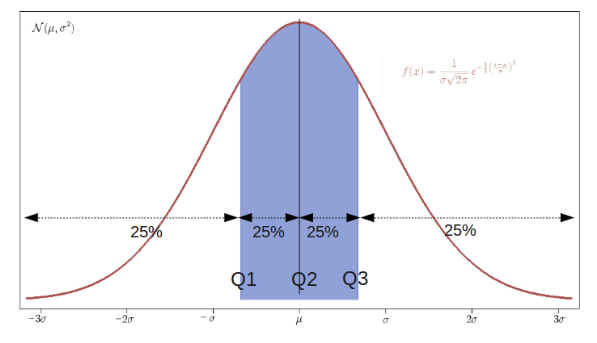

### Quantiles

In [ ]:
import yfinance as yf
data = yf.download('GGAL', start="2010-01-01")
data['variacion'] = data['Close'].pct_change() *100
data.dropna(inplace=True)
data['variacion_ranking'] = data.variacion.rank()
data['variacion_ranking_pct'] = data.variacion.rank(pct=True)
data

/tmp/ipython-input-3014635499.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('GGAL', start="2010-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,variacion,variacion_ranking,variacion_ranking_pct
Ticker,GGAL,GGAL,GGAL,GGAL,GGAL,,,
Date,,,,,,,,
2010-01-05,4.489400,4.496895,4.339504,4.339504,165900,3.454189,3457.0,0.866851
2010-01-06,4.219588,4.496896,4.189609,4.496896,239700,-6.009982,119.0,0.029840
2010-01-07,4.369484,4.376979,4.144640,4.144640,94100,3.552400,3479.0,0.872367
2010-01-08,4.294537,4.384474,4.122156,4.384474,136000,-1.715256,1015.0,0.254514
2010-01-11,4.129650,4.391969,4.054702,4.391969,145600,-3.839447,361.0,0.090522
...,...,...,...,...,...,...,...,...
2025-11-04,59.259998,60.919998,57.500000,57.500000,2390400,-2.516866,715.0,0.179288
2025-11-05,59.169998,61.200001,58.119999,60.910000,2173700,-0.151873,1877.0,0.470662


In [ ]:
data.variacion.quantile(0.612086) # el valor de variacion para el cual estoy en el percentil dado, en este caso percentil 0.103587

np.float64(0.73985709797677)

In [ ]:
data.variacion.quantile(0.05) # el famoso VaR sifuera una rueda como el 2.5% peor rueda de la historia

np.float64(-5.051239732796001)

### Ejercicio

    a - Traer los quantiles 0.05 y 0.95 de las variaciones diarias del SP500 desde el año 2005,
    b - Calcular el ratio del quantil 95 vs el 5 (en valor absoluto)
    c - Dar una interpretación de que significa el ratio
    d - Hacer el mismo cálculo para los siguientes tickers ['AAPL','AMZN','GOOGL','NFLX','GGAL','YPF','PAM']
    e - Sacar conclusiones
    
    f - ¿Que tipo de retornos debería tomar? ¿logaritmicos o lineales? ¿Por que?
    
    g- ¿Que pasa si quiero un ratio mas realista, es decir que contemple no solo los valores quantiles sino el agregado de toda una cola de la distribucion?  ¿Como debería hacer ese cálculo?

In [ ]:
import numpy as np
import yfinance as yf

# rachev ratio

tickers = ['SPY','AAPL','AMZN','GOOGL','NFLX','GGAL','YPF','PAM']
data = yf.download(tickers, start='2005-01-01')['Close']
ret_log = np.log(data / data.shift())
ret_log.quantile(.95).divide(ret_log.quantile(.05)).abs().round(4)

/tmp/ipython-input-1651053831.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2005-01-01')['Close']
[*********************100%***********************]  8 of 8 completed


,0
Ticker,
AAPL,1.0500
AMZN,1.0643
GGAL,1.0365
GOOGL,0.9816
NFLX,1.1045
PAM,1.0864
SPY,0.9114
YPF,1.0896


### Ideas para practicar

#### Hipótesis

> * Hay una variabildiad importante en los retornos en función del día de semana

#### Buscamos una lista de tickers

In [ ]:
# otra opcion
pd.read_html("https://www.slickcharts.com/sp500")[0]

,#,Company,Symbol,Weight,Price,Chg,% Chg
0,1,Nvidia,NVDA,7.87%,199.08,10.93,(5.81%)
1,2,Apple Inc.,AAPL,6.46%,269.22,0.74,(0.28%)
2,3,Microsoft,MSFT,6.10%,505.87,9.05,(1.82%)
3,4,Amazon,AMZN,4.31%,248.38,3.97,(1.62%)
4,5,Alphabet Inc. (Class A),GOOGL,2.94%,290.33,11.50,(4.12%)
...,...,...,...,...,...,...,...
498,499,Match Group,MTCH,0.01%,32.93,0.05,(0.17%)
499,500,Solstice Advanced Materials Inc.,SOLS,0.01%,47.76,0.27,(0.56%)
500,501,Molina Healthcare,MOH,0.01%,141.00,-11.06,(-7.27%)
501,502,Mohawk Industries,MHK,0.01%,108.08,-0.61,(-0.57%)


In [ ]:
import pandas as pd

url = "https://www.slickcharts.com/sp500"
sp500_tickers = pd.read_html(url)[0]

sp500_tickers = list(sp500_tickers.Symbol)
sp500_tickers = [e for e in sp500_tickers if e not in ('BRK.B','BF.B')]

print(sp500_tickers[:100])

['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'GOOG', 'AVGO', 'META', 'TSLA', 'JPM', 'LLY', 'WMT', 'ORCL', 'V', 'XOM', 'MA', 'NFLX', 'PLTR', 'JNJ', 'COST', 'AMD', 'BAC', 'ABBV', 'HD', 'PG', 'GE', 'CVX', 'KO', 'IBM', 'UNH', 'MU', 'CSCO', 'WFC', 'CAT', 'MS', 'AXP', 'GS', 'RTX', 'PM', 'TMUS', 'CRM', 'APP', 'ABT', 'TMO', 'MRK', 'MCD', 'LRCX', 'ISRG', 'DIS', 'LIN', 'UBER', 'PEP', 'AMAT', 'QCOM', 'INTC', 'C', 'INTU', 'NOW', 'NEE', 'T', 'APH', 'ANET', 'AMGN', 'SCHW', 'BLK', 'VZ', 'TJX', 'BKNG', 'KLAC', 'GEV', 'ACN', 'BSX', 'DHR', 'SPGI', 'ETN', 'BA', 'GILD', 'PANW', 'TXN', 'COF', 'CRWD', 'PFE', 'ADBE', 'SYK', 'UNP', 'WELL', 'LOW', 'DE', 'PGR', 'HON', 'HOOD', 'MDT', 'PLD', 'ADI', 'BX', 'CB', 'CEG', 'COP', 'KKR', 'PH']


#### Bajamos los cierres diarios de esos tickers

In [ ]:
%%time

import yfinance as yf
import numpy as np

tickers = sp500_tickers
cierres = yf.download(tickers, start='2000-01-01')['Close']

<timed exec>:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
[*********************100%***********************]  501 of 501 completed


CPU times: user 59.2 s, sys: 2.77 s, total: 1min 1s
Wall time: 2min 29s


In [ ]:
pd.options.display.max_columns = 8
cierres

Ticker,A,AAPL,ABBV,ABNB,...,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,
2000-01-03,43.113319,0.840094,NaN,NaN,...,4.545773,NaN,25.027779,NaN
2000-01-04,39.819939,0.769266,NaN,NaN,...,4.454401,NaN,24.666668,NaN
2000-01-05,37.349903,0.780523,NaN,NaN,...,4.477245,NaN,25.138889,NaN
2000-01-06,35.927746,0.712978,NaN,NaN,...,4.439175,NaN,23.777779,NaN
2000-01-07,38.921753,0.746750,NaN,NaN,...,4.340189,NaN,23.513889,NaN
...,...,...,...,...,...,...,...,...,...
2025-11-04,146.080002,270.040009,215.889999,122.349998,...,149.550003,103.180000,260.350006,124.459999
2025-11-05,146.770004,270.140015,216.770004,122.500000,...,149.389999,87.550003,266.269989,120.489998
2025-11-06,147.490005,269.769989,219.039993,120.529999,...,147.610001,88.510002,258.239990,119.559998


#### Armamos una matriz de retornos y una de resumen

> ⚠️ Vamos a usar retornos logaritmicos para poder sacar promedios y que tenga sentido

In [ ]:
retornos = np.log((cierres/cierres.shift(1)))

mat_ret = retornos.groupby(retornos.index.dayofweek).mean()*250

mat_ret = mat_ret.clip(lower=-1, upper=1)
mat_ret.index = ['Lunes','Martes','Miercoles','Jueves','Viernes']
resumen = mat_ret.transpose()
resumen.describe()

,Lunes,Martes,Miercoles,Jueves,Viernes
count,501.000000,501.000000,501.000000,501.000000,501.000000
mean,-0.011214,0.185115,0.120042,0.121381,0.148069
std,0.219301,0.179064,0.194486,0.209346,0.199500
min,-1.000000,-0.983480,-1.000000,-1.000000,-1.000000
25%,-0.141716,0.081734,0.008359,0.023730,0.047424
50%,-0.019369,0.179704,0.094690,0.121448,0.147919
75%,0.103355,0.287512,0.207719,0.234643,0.234582
max,1.000000,1.000000,1.000000,1.000000,0.998558


In [ ]:
mat_ret

Ticker,A,AAPL,ABBV,ABNB,...,YUM,ZBH,ZBRA,ZTS
Lunes,-0.204657,0.692831,-0.010674,-0.537369,...,0.049960,-0.180864,-0.107419,-0.207592
Martes,0.103542,0.217136,-0.011195,0.329593,...,0.130383,0.247884,0.225354,0.106093
Miercoles,-0.017476,0.291349,0.286589,-0.096496,...,0.190149,0.069743,0.081839,-0.043043
Jueves,0.191641,0.238664,0.198047,-0.315826,...,0.272862,-0.084309,0.139538,0.447156
Viernes,0.145364,-0.301214,0.434573,0.383170,...,0.018850,0.181123,0.094992,0.241980


#### Graficamos

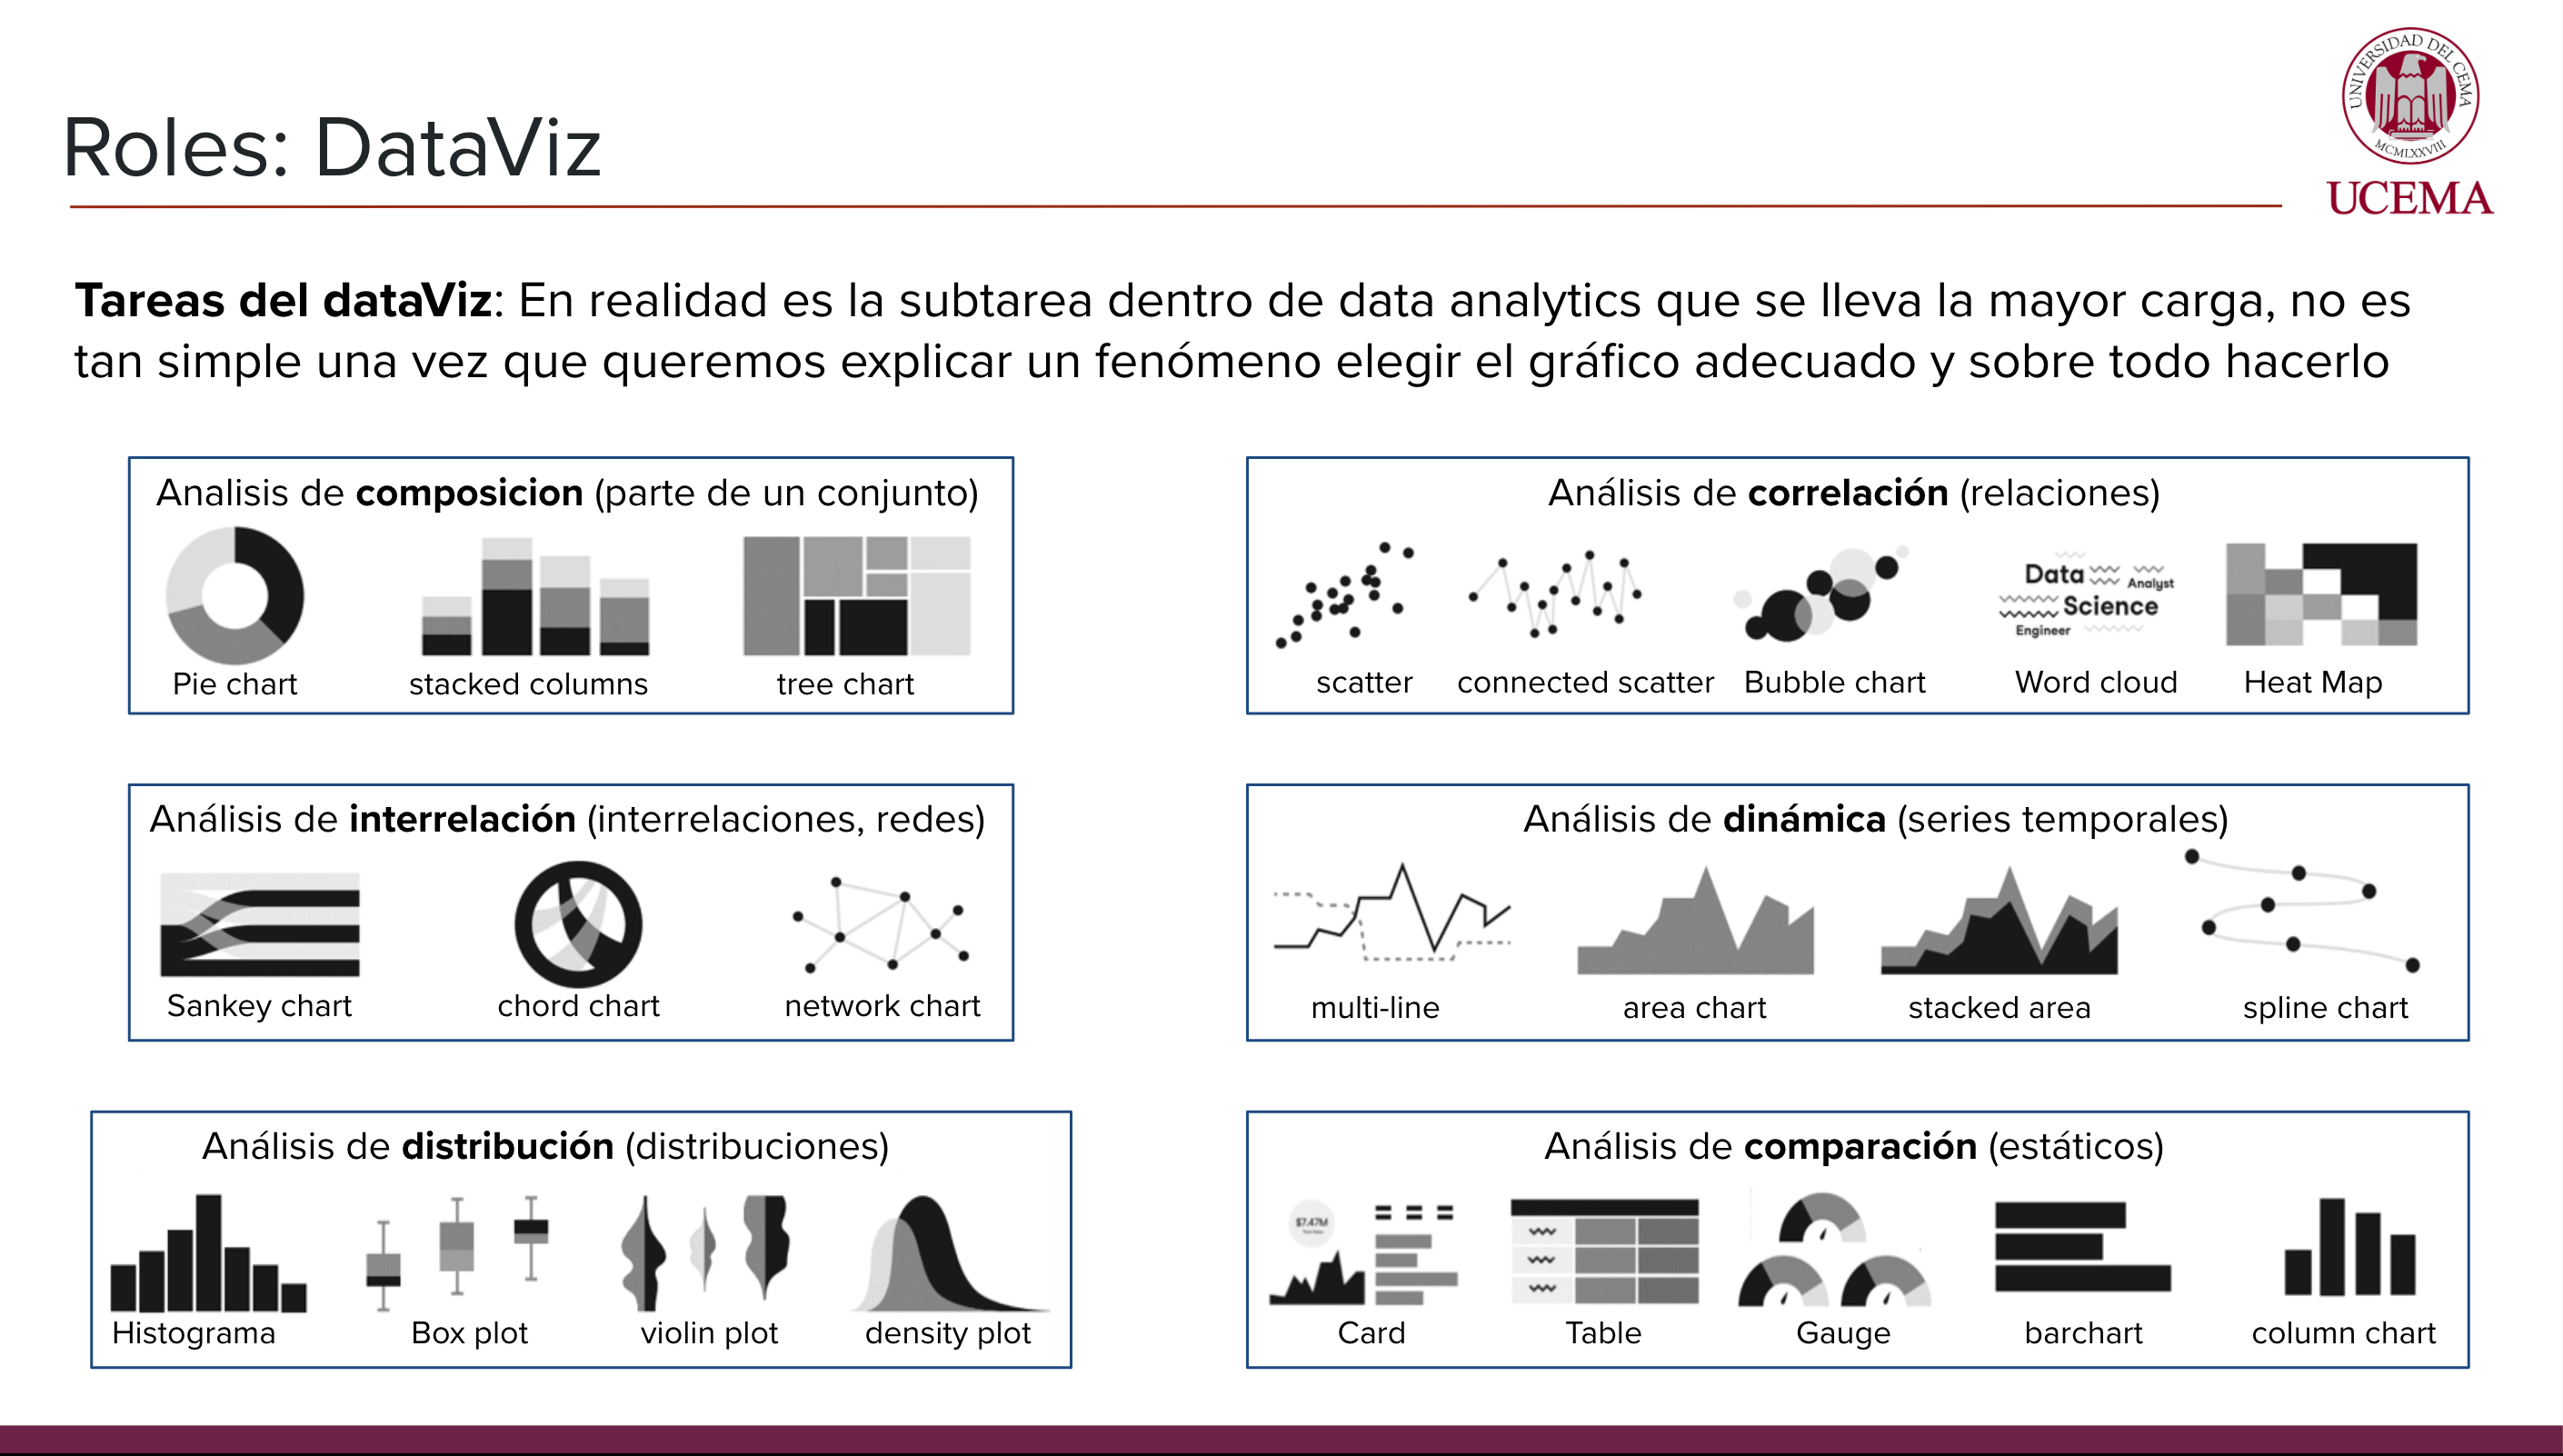

array([[<Axes: title={'center': 'Lunes'}>,
        <Axes: title={'center': 'Martes'}>],
       [<Axes: title={'center': 'Miercoles'}>,
        <Axes: title={'center': 'Jueves'}>],
       [<Axes: title={'center': 'Viernes'}>, <Axes: >]], dtype=object)

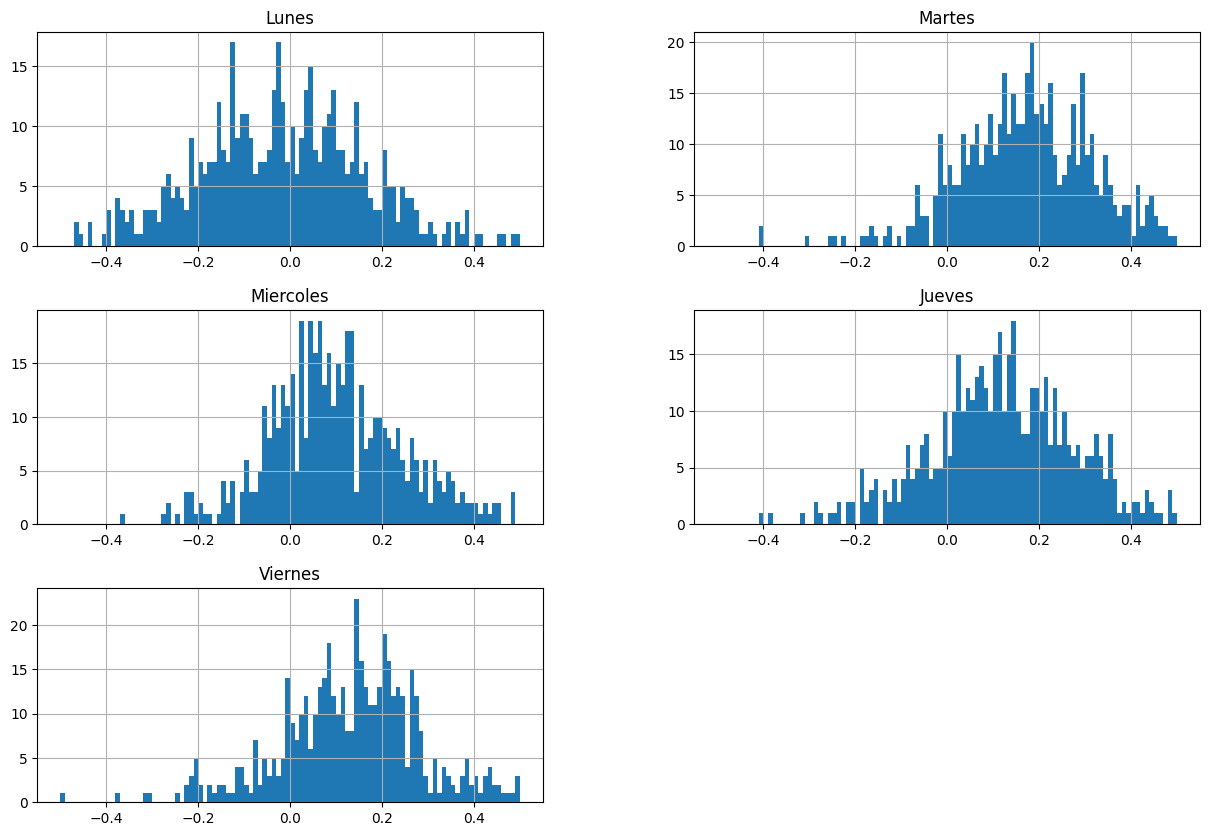

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('default')
resumen.hist(figsize=(15,10), bins=100, range=(-0.5,0.5))

<Axes: xlabel='Ticker'>

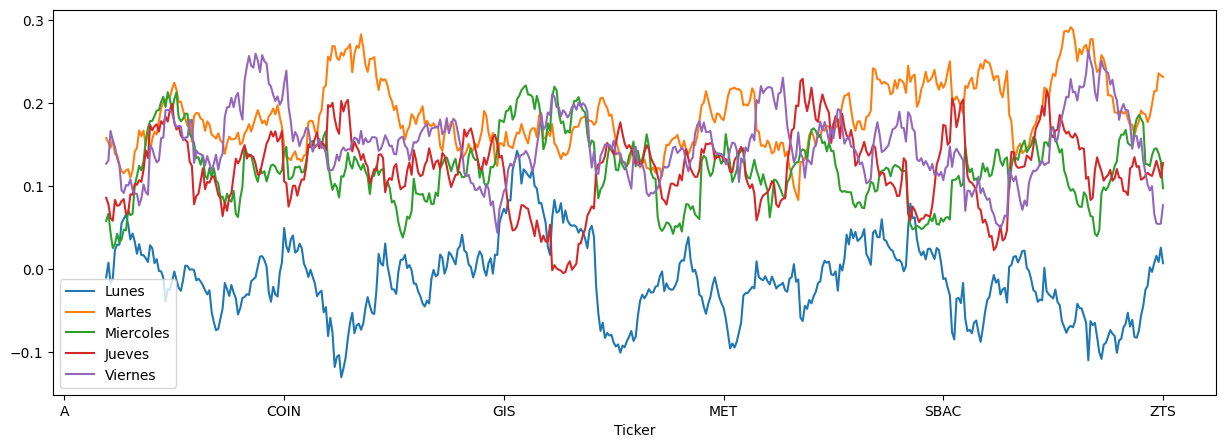

In [ ]:
resumen.rolling(20).mean().plot(figsize=(15,5))

<Axes: xlabel='Ticker'>

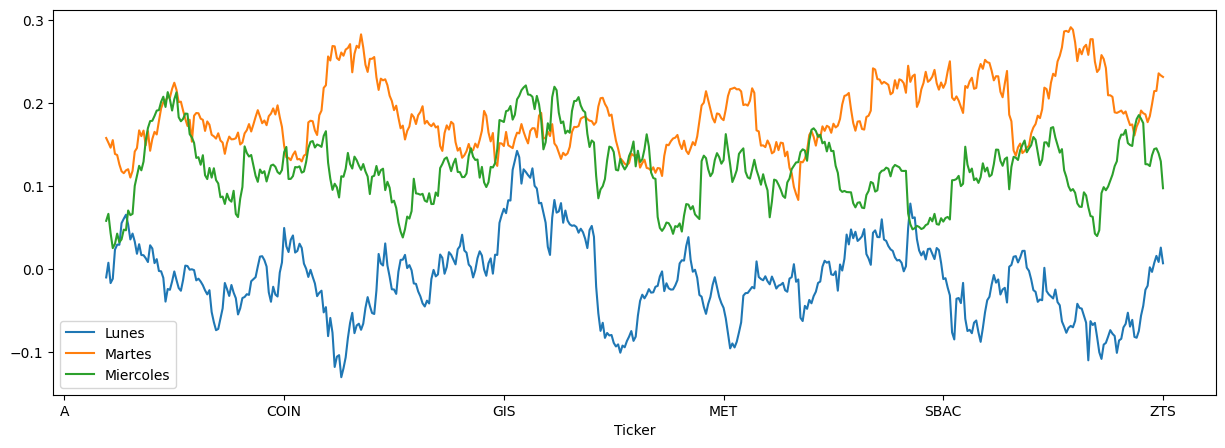

In [ ]:
df1 = resumen['Lunes'].rolling(20).mean()
df2 = resumen['Martes'].rolling(20).mean()
df3 = resumen['Miercoles'].rolling(20).mean()

df_todos=  pd.concat([df1,df2,df3], axis=1)
df_todos.plot(figsize=(15,5))

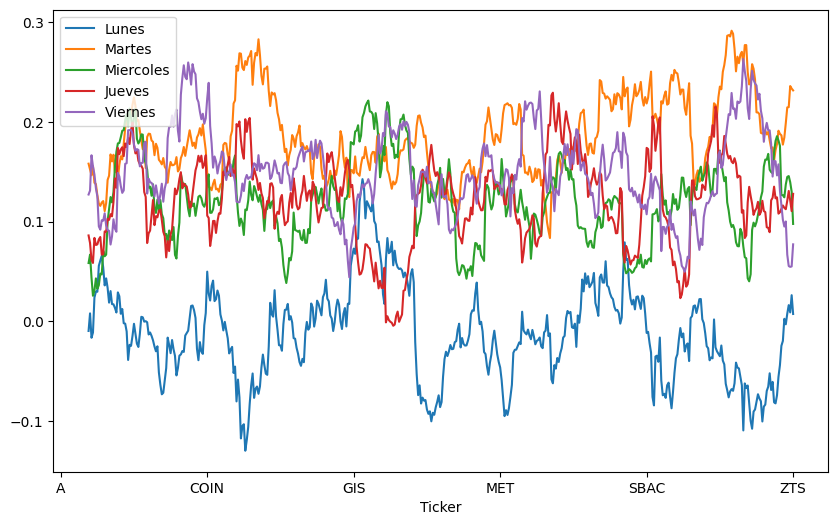

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for dia in resumen.columns:
    resumen[dia].rolling(20).mean().plot()


plt.legend(loc='upper left')

<Axes: ylabel='Frequency'>

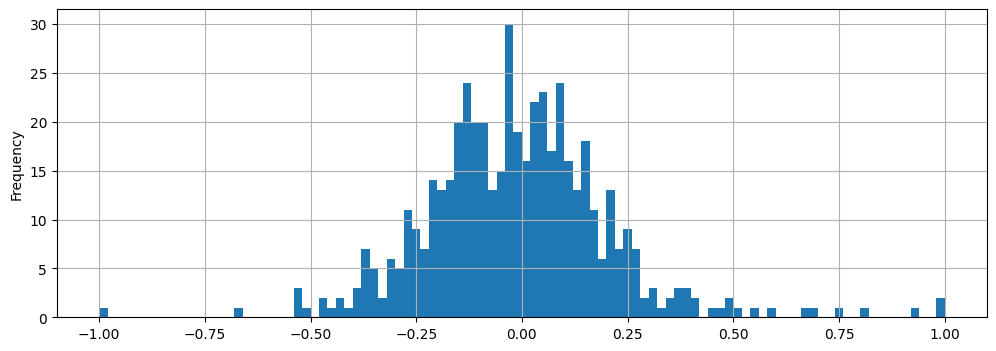

In [ ]:
resumen.Lunes.plot(kind='hist', bins=100, grid=True, figsize=(12,4), range=(-1,1))

<Axes: ylabel='Frequency'>

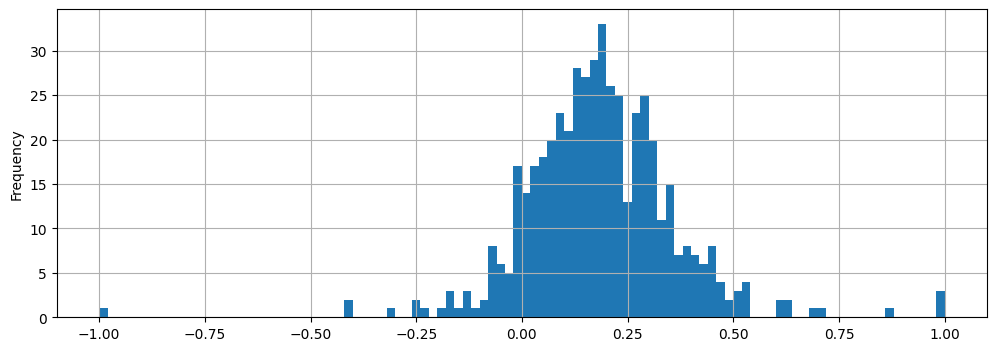

In [ ]:
resumen.Martes.plot(kind='hist', bins=100, grid=True, figsize=(12,4), range=(-1,1))

### BoxPlot

<Axes: >

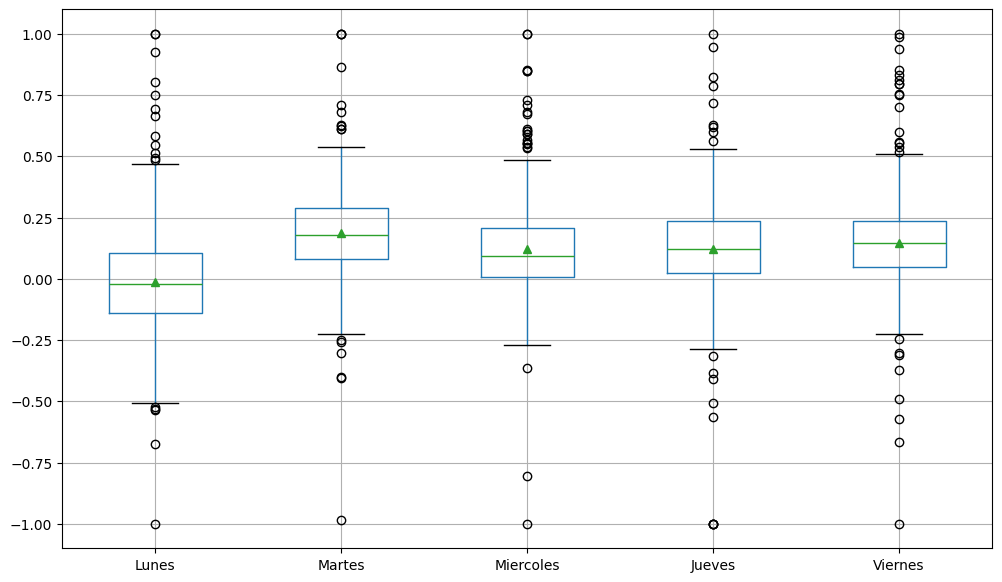

In [ ]:
pd.plotting.boxplot_frame(resumen, whis=1.5, showmeans=True, figsize=(12,7))

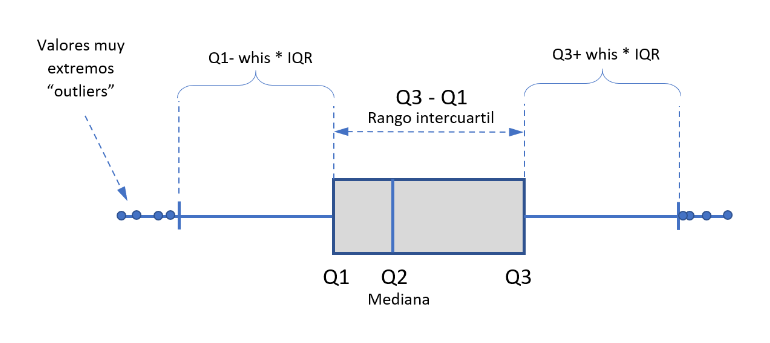

# Funciones Acumulativas

Las funciones acumulativas nos permiten trabajar en la fila "n" de una tabla con todos los datos de las filas "0 a n"
<br>Dentro de este tipo de funciones encontramos:

* cummax()  El máximo acumulado (ideal para máximo histórico por fecha)
* cummin()  El mínimo acumulado (ideal para mínimo histórico por fecha)
* cumsum() La suma acumulada (ideal para armado se subtotales por fecha)
* cumprod() El producto acumulado (ideal para rendimiento compuesto)

## Cummax()

El uso típico que le vamos a dar a esta función es para saber el máximo histórico de una serie en cada punto de la misma

In [ ]:
data = yf.download('GGAL', start="2018-01-01", auto_adjust=True)
data = data.drop(["High","Low","Volume"], axis=1)

data['maxHist'] = data.Close.cummax()
data.head(6)

[*********************100%***********************]  1 of 1 completed


Price,Close,Open,maxHist
Ticker,GGAL,GGAL,
Date,,,
2018-01-02,51.539688,51.071912,51.539688
2018-01-03,51.317299,51.631708,51.539688
2018-01-04,53.303432,51.401653,53.303432
2018-01-05,52.720623,53.625501,53.303432
2018-01-08,51.133255,52.498239,53.303432
2018-01-09,51.470665,51.301958,53.303432


<Axes: xlabel='Date'>

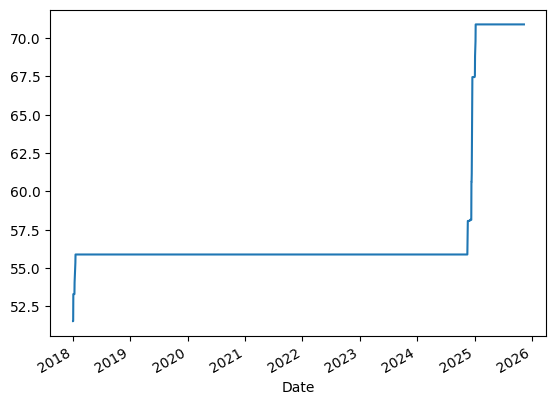

In [ ]:
data.maxHist.plot()

## Cummin()

Obviamente es lo mismo que el cummax pero para mínimos, la combinación de cummax() y cummin() va a ser muy util para backtestings de drawdowns y recuperaciones posteriores

In [ ]:
data['minHist'] = data.Close.cummin()
data.head(6)

Price,Close,Open,maxHist,minHist
Ticker,GGAL,GGAL,,
Date,,,,
2018-01-02,51.539688,51.071912,51.539688,51.539688
2018-01-03,51.317299,51.631708,51.539688,51.317299
2018-01-04,53.303432,51.401653,53.303432,51.317299
2018-01-05,52.720623,53.625501,53.303432,51.317299
2018-01-08,51.133255,52.498239,53.303432,51.133255
2018-01-09,51.470665,51.301958,53.303432,51.133255


<Axes: xlabel='Date'>

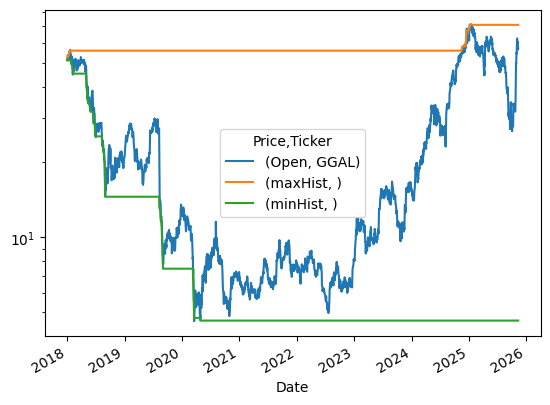

In [ ]:
data.iloc[:, -3: ].plot(logy=True)

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

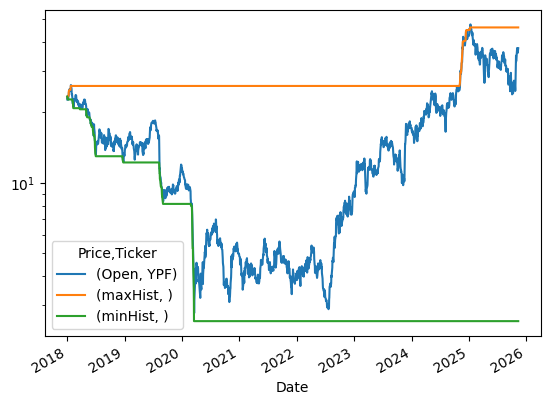

In [ ]:
data = yf.download('YPF', start="2018-01-01",auto_adjust=True)
data['maxHist'] = data.Close.cummax()
data['minHist'] = data.Close.cummin()
data = data.drop(["High","Low","Volume"], axis=1)
data.iloc[:, -3: ].plot(logy=True)

## Cumsum()

Cumsum() es obviamente una funcion de sumas acumuladas, que en la posicion de la fila "n" nos devuelve la suma de "0 a n" (inclusive)

$$ \large cumsum\hspace{3mm}(X_{n})\hspace{3mm}  =  \hspace{3mm} \sum_{i=0}^{n}x_{i} $$

En el ejemplo aprovechamos para borrar las columnas de OHLC par limpiar un poco la salida con la función drop()

In [ ]:
data = yf.download('GGAL', auto_adjust=True)
data['volumenAcum'] = data.Volume.cumsum()/1000000
data = data.drop(['Open','High','Low','Close'], axis=1).dropna().round(2)
data.head(6)

[*********************100%***********************]  1 of 1 completed


Price,Volume,volumenAcum
Ticker,GGAL,
Date,,
2000-07-25,126200,0.13
2000-07-26,28900,0.16
2000-07-27,61200,0.22
2000-07-28,146100,0.36
2000-07-31,178400,0.54
2000-08-01,87400,0.63


<Axes: xlabel='Date'>

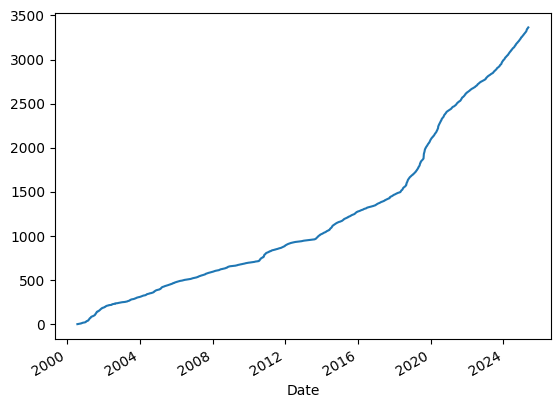

In [ ]:
data.volumenAcum.plot()

## Cumprod()

Cumprod() es una función de productorio, es decir el producto acumulado de 0 a n, para la fila n

$$ \large cumprod\hspace{3mm}(X_{n})\hspace{3mm}  =  \hspace{3mm} \prod_{i=0}^{n}x_{i} $$

Vamos a usar esta fórmula para calcular rendimiento compuesto, es muy sencillo:
<br>  1- Creamos una columna "variacion" con el valor "r", rendimiento porcentual diario.
<br>  2- Creamos una columna "factor" con el valor (1+r)
<br>  2- Luego vamos a aplicar el productorio para cada fila de esa columna "factor" y le restamos 1 al resultado.

In [ ]:
data = yf.download('GGAL', start="2015-01-01",auto_adjust=True)

data['variacion'] = data['Close'].pct_change()
data['factor'] = 1 + data['variacion']
data['rendimientoAcum'] = (data.factor.cumprod()-1)*100
data['base100'] = (data.factor.cumprod())*100

data = data.drop(['Open','High','Low','Close','Volume'],axis=1).dropna().round(4)
data

[*********************100%***********************]  1 of 1 completed


Price,variacion,factor,rendimientoAcum,base100
Ticker,,,,
Date,,,,
2015-01-05,-0.0250,0.9750,-2.5048,97.4952
2015-01-06,0.0000,1.0000,-2.5048,97.4952
2015-01-07,0.0204,1.0204,-0.5138,99.4862
2015-01-08,0.0245,1.0245,1.9268,101.9268
2015-01-09,0.0013,1.0013,2.0552,102.0552
...,...,...,...,...
2025-11-04,-0.0252,0.9748,401.2609,501.2609
2025-11-05,-0.0015,0.9985,400.4996,500.4996


<Axes: xlabel='Date'>

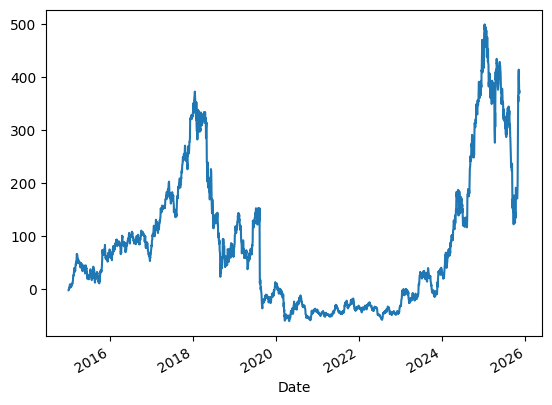

In [ ]:
data.rendimientoAcum.plot()

<Axes: xlabel='Date'>

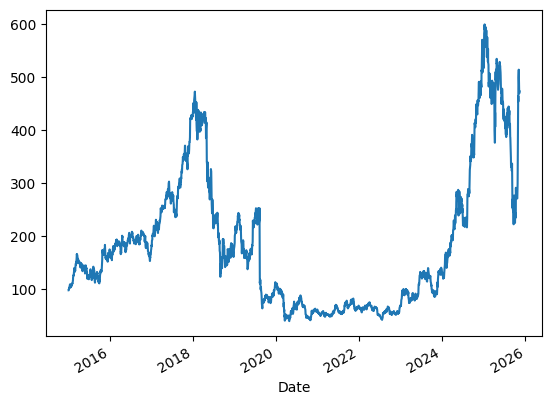

In [ ]:
data.base100.plot()

## Algo mas avanzado de MatPlotLib

/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:1477: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(y))
/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:763: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(y))
/usr/local/lib/python3.12/dist-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))


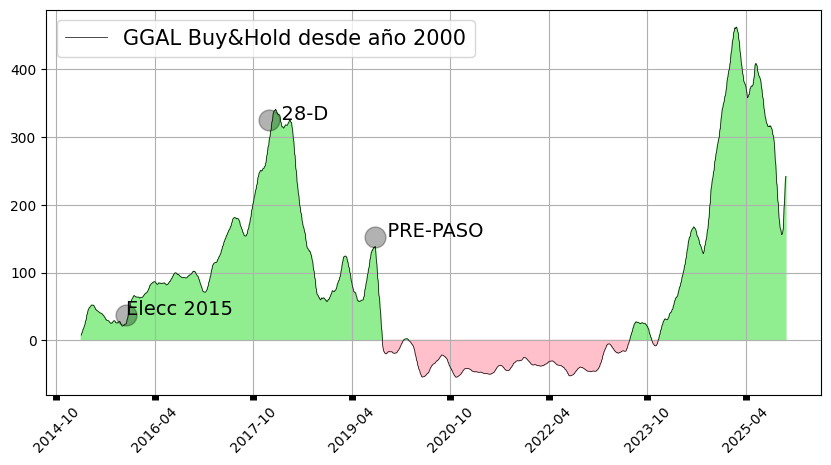

In [ ]:
import matplotlib.pyplot as plt


import matplotlib.dates as mdates
from datetime import datetime as dtdt

fig, ax = plt.subplots(figsize=(10,5))

# Ploteo
curva = data.rendimientoAcum.rolling(30).mean()

# c es color
# ls es linestyle
# lw es linewidth

ax.plot(curva, c='k', ls='-', lw=.5, label='GGAL Buy&Hold desde año 2000')

ax.fill_between(data.index, curva, 0, where=curva < 0 ,color='pink')
ax.fill_between(data.index, curva, 0, where=curva > 0 ,color='lightgreen')

ax.legend(loc='upper left', fontsize=15)

# ticks y labels
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=18))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45, labelsize=10, width=5)
ax.grid()

# Anotaciones
eventos = { "Elecc 2015": dtdt(2015,10,23), "  28-D" : dtdt(2017,12,28),  '  PRE-PASO' : dtdt(2019,8,9) }
for k,v in eventos.items():
    ax.plot(eventos[k], data.loc[v].rendimientoAcum, 'ko', markersize=15, alpha=.3)
    ax.annotate(k, xy=(v,data.loc[v].rendimientoAcum), fontsize=14)

## Rolling vs Acumulativas vs Descriptivas (diferencias)
* cummax vs rolling(n).max() vs max()
* cummin vs rolling(n).min() vs min()
* cumsum vs rolling(n).sum() vs sum()



## Reflexionar diferencias y casos de uso

look-ahead Bias, leakage

# Agrupamiento

In [ ]:
data = yf.download('GGAL', start="2005-01-01", auto_adjust=True)
data['variacion'] = data['Close'].pct_change()
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,variacion
Ticker,GGAL,GGAL,GGAL,GGAL,GGAL,
Date,,,,,,
2005-01-03,6.318139,6.520499,6.280665,6.400582,118300,NaN
2005-01-04,6.175738,6.385594,6.153254,6.318140,97100,-0.022538
2005-01-05,6.085798,6.168241,5.958386,6.078303,289700,-0.014563
2005-01-06,6.243191,6.265675,6.055820,6.130769,285100,0.025862
2005-01-07,6.108284,6.258182,6.078305,6.153254,160300,-0.021609
...,...,...,...,...,...,...
2025-11-04,59.259998,60.919998,57.500000,57.500000,2390400,-0.025169
2025-11-05,59.169998,61.200001,58.119999,60.910000,2173700,-0.001519


## Agrupamiento - Indices de fechas

### Por día de la semana

In [ ]:
agrupados = data.Volume.groupby(data.index.dayofweek).sum()
agrupados

Ticker,GGAL
Date,
0,634956671
1,695488000
2,671239800
3,654589000
4,617368800


### Por trimestre

In [ ]:
agrupados = data.Close.groupby(data.index.to_period('Q')).last()
agrupados

Ticker,GGAL
Date,
2005Q1,5.651098
2005Q2,6.048325
2005Q3,6.498015
2005Q4,5.178926
2006Q1,5.778512
...,...
2024Q4,61.178768
2025Q1,53.472523
2025Q2,49.703297


### Por año

<Axes: xlabel='Date'>

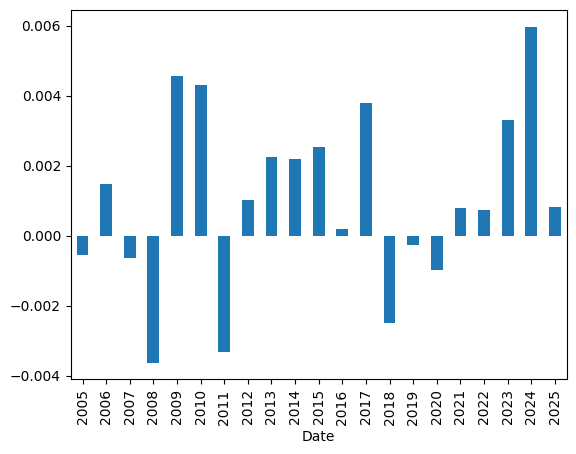

In [ ]:
agrupados = data.variacion.groupby(data.index.to_period('Y')).mean()
agrupados.plot(kind='bar')

### Por mas de un criterio

In [ ]:
agrupados = data.groupby([data.index.year, data.index.dayofweek]).sum()
agrupados.head(20)

Price           Close        High         Low        Open    Volume variacion
Ticker           GGAL        GGAL        GGAL        GGAL      GGAL          
Date Date                                                                    
2005 0     281.026043  286.317391  276.596601  282.285173  14410400 -0.103190
     1     317.473377  323.236901  312.766630  318.432717  18992900 -0.057631
     2     316.851316  322.652314  311.567463  317.848130  16068600 -0.074709
     3     311.739841  317.585804  305.796441  311.110273  21252800  0.151121
     4     311.792311  318.095462  307.685146  312.894051  16645700 -0.055211
2006 0     240.179230  244.001593  236.124530  240.868754   7043000 -0.065012
     1     268.142429  272.429470  262.858575  267.332988   9684000  0.083789
     2     274.288199  278.073088  269.281655  273.321366  11926800  0.295187
     3     269.071792  272.257093  263.675517  268.742020   9237200  0.130244
     4     268.951883  272.879172  264.739789  269.131758   9911200 -0.075227
2007 0     324.293684  330.566853  319.129747  324.788343  12163900 -0.083971
     1     340.752314  347.834925  335.648336  343.308051  12048900 -0.140815
     2     346.133603  352.863956  340.332607  346.868095  13058900  0.025608
     3     347.167902  353.336147  340.677382  347.984840  15695300 -0.089997
     4     345.706396  352.376788  339.688049  346.920558  15570700  0.125769
2008 0     172.470963  178.849061  167.494398  174.232247  11294800 -0.323171
     1     189.686586  196.424438  184.207869  191.208038  14534300 -0.153555
     2     194.730608  200.718976  189.461745  195.607502  13396300 -0.289334
     3     190.113787  195.442610  184.732503  191.005672  11482300 -0.017869
     4     182.641439  188.734733  177.769802  183.450880  12943500 -0.133489

## Agrupamientos lógicos y variables categóricas

###  Ejercicio de repaso

Dado el diccionario que representa los valores tope de "segmentos de volatilidad":
       
       regimenes = {'Baja':0.4, 'Media':.6, 'Alta':99}  
    
Crear una lista de los delimitadores de cada segmento que comience por 0

### Segmentación

In [ ]:
data = yf.download('GGAL', start="2005-01-01", auto_adjust=True)

data['variacion'] = data['Close'].pct_change()
data['volatilidad'] = data.variacion.rolling(250).std() * 250**0.5
data.dropna(inplace=True)

regimenes = {'Baja':0.4, 'Media':.6, 'Alta':99}
bins = [0] + list(regimenes.values())

data['regimen'] = pd.cut(data.volatilidad, bins=bins, labels=list(regimenes.keys()))
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,variacion,volatilidad,regimen
Ticker,GGAL,GGAL,GGAL,GGAL,GGAL,,,
Date,,,,,,,,
2005-12-29,5.231389,5.321327,5.171430,5.223894,235300,0.005763,0.344752,Baja
2005-12-30,5.178924,5.268862,5.148945,5.223893,59100,-0.010029,0.344176,Baja
2006-01-03,5.253874,5.441245,5.193915,5.216400,382400,0.014472,0.344207,Baja
2006-01-04,5.321328,5.456235,5.306338,5.426255,814900,0.012839,0.343457,Baja
2006-01-05,5.313833,5.411265,5.268864,5.396276,281100,-0.001408,0.342798,Baja
...,...,...,...,...,...,...,...,...
2025-11-04,59.259998,60.919998,57.500000,57.500000,2390400,-0.025169,0.778282,Alta
2025-11-05,59.169998,61.200001,58.119999,60.910000,2173700,-0.001519,0.778289,Alta


In [ ]:
data.groupby('regimen').size()

/tmp/ipython-input-2706058967.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('regimen').size()


,0
regimen,
Baja,1069
Media,2884
Alta,1045


### Ejercicio

    Con esta matriz, extraer la variación diaria que delimita al primer y último decil de cada régimen de volatilidad
    Razonar utilidad de este tipo de ejercicio

## Métodos para concatenar a los agrupamientos

Así como usamos la funcón count() podemos usar otro tipo de funciones, por ejemplo:
* first()
* last()
* min()
* max()
* sum()
* prod()
* mean()
* median()
* std() desvio estandar (sigma)
* var() varianza (sigma^2)
* skew()  (Coeficiente de asimetria)
* kurtosis()
* quantile()  

# Mas funciones

## Clip (Acotado)

In [ ]:
tabla = yf.download(['AAPL','SPY','QQQ'], start="2001-01-01", auto_adjust=True)['Close'].pct_change().dropna() *100
tabla

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,QQQ,SPY
Date,,,
2001-01-03,10.084167,16.842123,4.803517
2001-01-04,4.198521,-1.801831,-1.076361
2001-01-05,-4.029348,-7.645232,-3.264298
2001-01-08,1.144920,1.103716,0.774027
2001-01-09,3.773672,0.000000,-0.264043
...,...,...,...
2025-11-04,0.367969,-2.029809,-1.185360
2025-11-05,0.037034,0.650792,0.346547
2025-11-06,-0.136975,-1.862734,-1.072939


In [ ]:
tabla_acotada = tabla.clip(-4,4)
tabla_acotada

Ticker,AAPL,QQQ,SPY
Date,,,
2001-01-03,4.000000,4.000000,4.000000
2001-01-04,4.000000,-1.801831,-1.076361
2001-01-05,-4.000000,-4.000000,-3.264298
2001-01-08,1.144920,1.103716,0.774027
2001-01-09,3.773672,0.000000,-0.264043
...,...,...,...
2025-11-04,0.367969,-2.029809,-1.185360
2025-11-05,0.037034,0.650792,0.346547
2025-11-06,-0.136975,-1.862734,-1.072939


# Repaso de Estadística 2

## Desvío Estandrar - Fórmulas

El desvio es el sigma, la varianza es el sigma cuadrado

$$ \large \sigma^2 = \frac{1}{n}  \sum_{x=i}^{n} . (X_i - \bar{X} )^2  $$

In [ ]:
tabla.std()

,0
Ticker,
AAPL,2.221733
QQQ,1.564879
SPY,1.210963


## Error estandar - Fórmulas

$$ \Large \frac{\sigma}{\sqrt{n}}$$

In [ ]:
tabla.sem()

,0
Ticker,
AAPL,0.028101
QQQ,0.019793
SPY,0.015316


## Varianza

In [ ]:
tabla.std()**2

,0
Ticker,
AAPL,4.936099
QQQ,2.448845
SPY,1.466432


In [ ]:
tabla.var()

,0
Ticker,
AAPL,4.936099
QQQ,2.448845
SPY,1.466432


## Skew - Fórmulas

$$ \large  skew =  \frac{\mu_3}{\sigma^3}  =  \frac{\sum_{x=i}^{n} \frac{1}{n} . (X_i - \bar{X} )^3}{\sigma^3} $$

## Repaso de Coeficiente de Asimetría

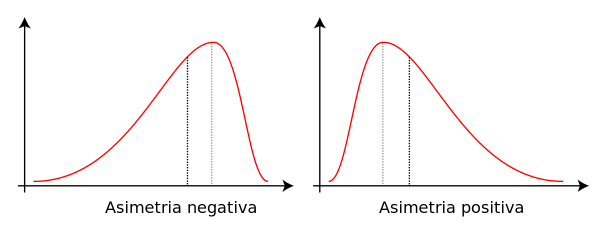

## Kurtosis

$$ \Large kurtosis = \frac{\sum_{i=1} (X_i-\bar{X})^4}{n . \sigma^4}$$


Coeficiente de apuntamiento

<div style="width:600px;float:left;">
    <br>La Curtosis nos da una idea de la forma, mientras mas alta, mas valores cerca de la media y mas gruesas las colas
    <ul>
        <li> Leptocúrtica,  Curtosis > 3 (más apuntada y con colas más gruesas que la normal) </li>
        <li> Platicúrtica,  Curtosis < 3 (menos apuntada y con colas menos gruesas que la norma) </li>
        <li> Mesocúrtica,   Curtosis = 3 (tiene una distribución normal) </li>
    </ul>
</div>
<div style="width:350px;float:right;margin-top:-25px;">
    <img src="./imagenes/kurtosis.png" style="width:300px;height:230px;">
</div>


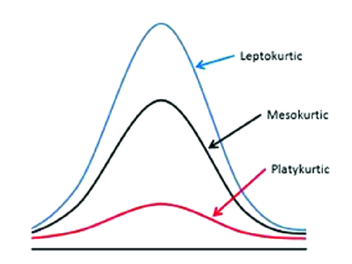

In [ ]:
tabla.kurt()

,0
Ticker,
AAPL,5.519647
QQQ,7.946806
SPY,12.882349


In [ ]:
tabla.skew()

,0
Ticker,
AAPL,0.121106
QQQ,0.196734
SPY,0.024913


In [ ]:
tabla.var()

,0
Ticker,
AAPL,4.936099
QQQ,2.448845
SPY,1.466432


## Covarianza

$$ \large s_{xy}={1 \over n}\sum _{i=1}^{n}{(x_{i}-{\overline {x}})(y_{i}-{\overline {y}})} $$

In [ ]:
import yfinance as yf

activos = ['GGAL','YPF','PAM','EDN','BBAR']
data = yf.download(activos, start='2001-01-01', end='2020-08-30', auto_adjust=True)['Close']
tabla = data.pct_change().dropna()*100
tabla

[*********************100%***********************]  5 of 5 completed


Ticker,BBAR,EDN,GGAL,PAM,YPF
Date,,,,,
2009-10-12,4.817533,5.421684,1.698118,1.176468,-0.656074
2009-10-13,-1.114203,1.714281,0.371039,-2.015503,1.447814
2009-10-14,-1.408459,0.000000,2.587812,-0.474689,0.300434
2009-10-15,-0.857140,-1.460665,-2.702716,-0.635922,1.098354
2009-10-16,-3.314120,1.368300,-1.666630,0.399997,-0.296298
...,...,...,...,...,...
2020-08-24,-0.903598,-5.660378,-0.494580,0.363967,0.934583
2020-08-25,1.823704,-2.857140,1.093443,1.450588,2.777779
2020-08-26,-3.283587,1.470587,-1.278256,2.234138,0.180176


In [ ]:
tabla.GGAL.cov(tabla.GGAL)

np.float64(12.465607874697339)

In [ ]:
tabla.GGAL.cov(tabla.EDN)

np.float64(7.626180828857016)

### Matriz de covarianzas

In [ ]:
tabla.cov()

Ticker,BBAR,EDN,GGAL,PAM,YPF
Ticker,,,,,
BBAR,12.709455,7.705110,10.337800,7.336794,5.841315
EDN,7.705110,16.075827,7.626181,7.554618,5.075765
GGAL,10.337800,7.626181,12.465608,7.344022,6.085247
PAM,7.336794,7.554618,7.344022,9.924349,4.742026
YPF,5.841315,5.075765,6.085247,4.742026,9.376967


In [ ]:
tabla.corr()

Ticker,BBAR,EDN,GGAL,PAM,YPF
Ticker,,,,,
BBAR,1.000000,0.539050,0.821312,0.653269,0.535077
EDN,0.539050,1.000000,0.538721,0.598101,0.413413
GGAL,0.821312,0.538721,1.000000,0.660277,0.562847
PAM,0.653269,0.598101,0.660277,1.000000,0.491566
YPF,0.535077,0.413413,0.562847,0.491566,1.000000
